In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import MinMaxScaler

Lets begin by examining the amount of energy produced from renewable sources

In [2]:
renewable = pd.read_csv('../data/energy_renewable.csv', parse_dates=['date'])
renewable

,date,energy_mwh
0,2020-11-30 00:00:00,150
1,2020-11-30 01:00:00,144
2,2020-11-30 02:00:00,178
3,2020-11-30 03:00:00,257
4,2020-11-30 04:00:00,277
...,...,...
19025,2023-01-31 19:00:00,2342
19026,2023-01-31 20:00:00,2241
19027,2023-01-31 21:00:00,1998
19028,2023-01-31 22:00:00,1944


In [3]:
renewable['year'] = renewable['date'].dt.year
renewable['day'] = pd.to_datetime(renewable['date']).dt.day
renewable['month'] = pd.to_datetime(renewable['date']).dt.month
renewable['hour'] = pd.to_datetime(renewable['date']).dt.hour

renewable = renewable[renewable.columns[1:]]

In [4]:
mean_energy_per_day = renewable.groupby(['year', 'month', 'day'])['energy_mwh'].mean().reset_index()

# Rename the column for clarity
mean_energy_per_day.rename(columns={'energy_mwh': 'mean_energy_mwh'}, inplace=True)


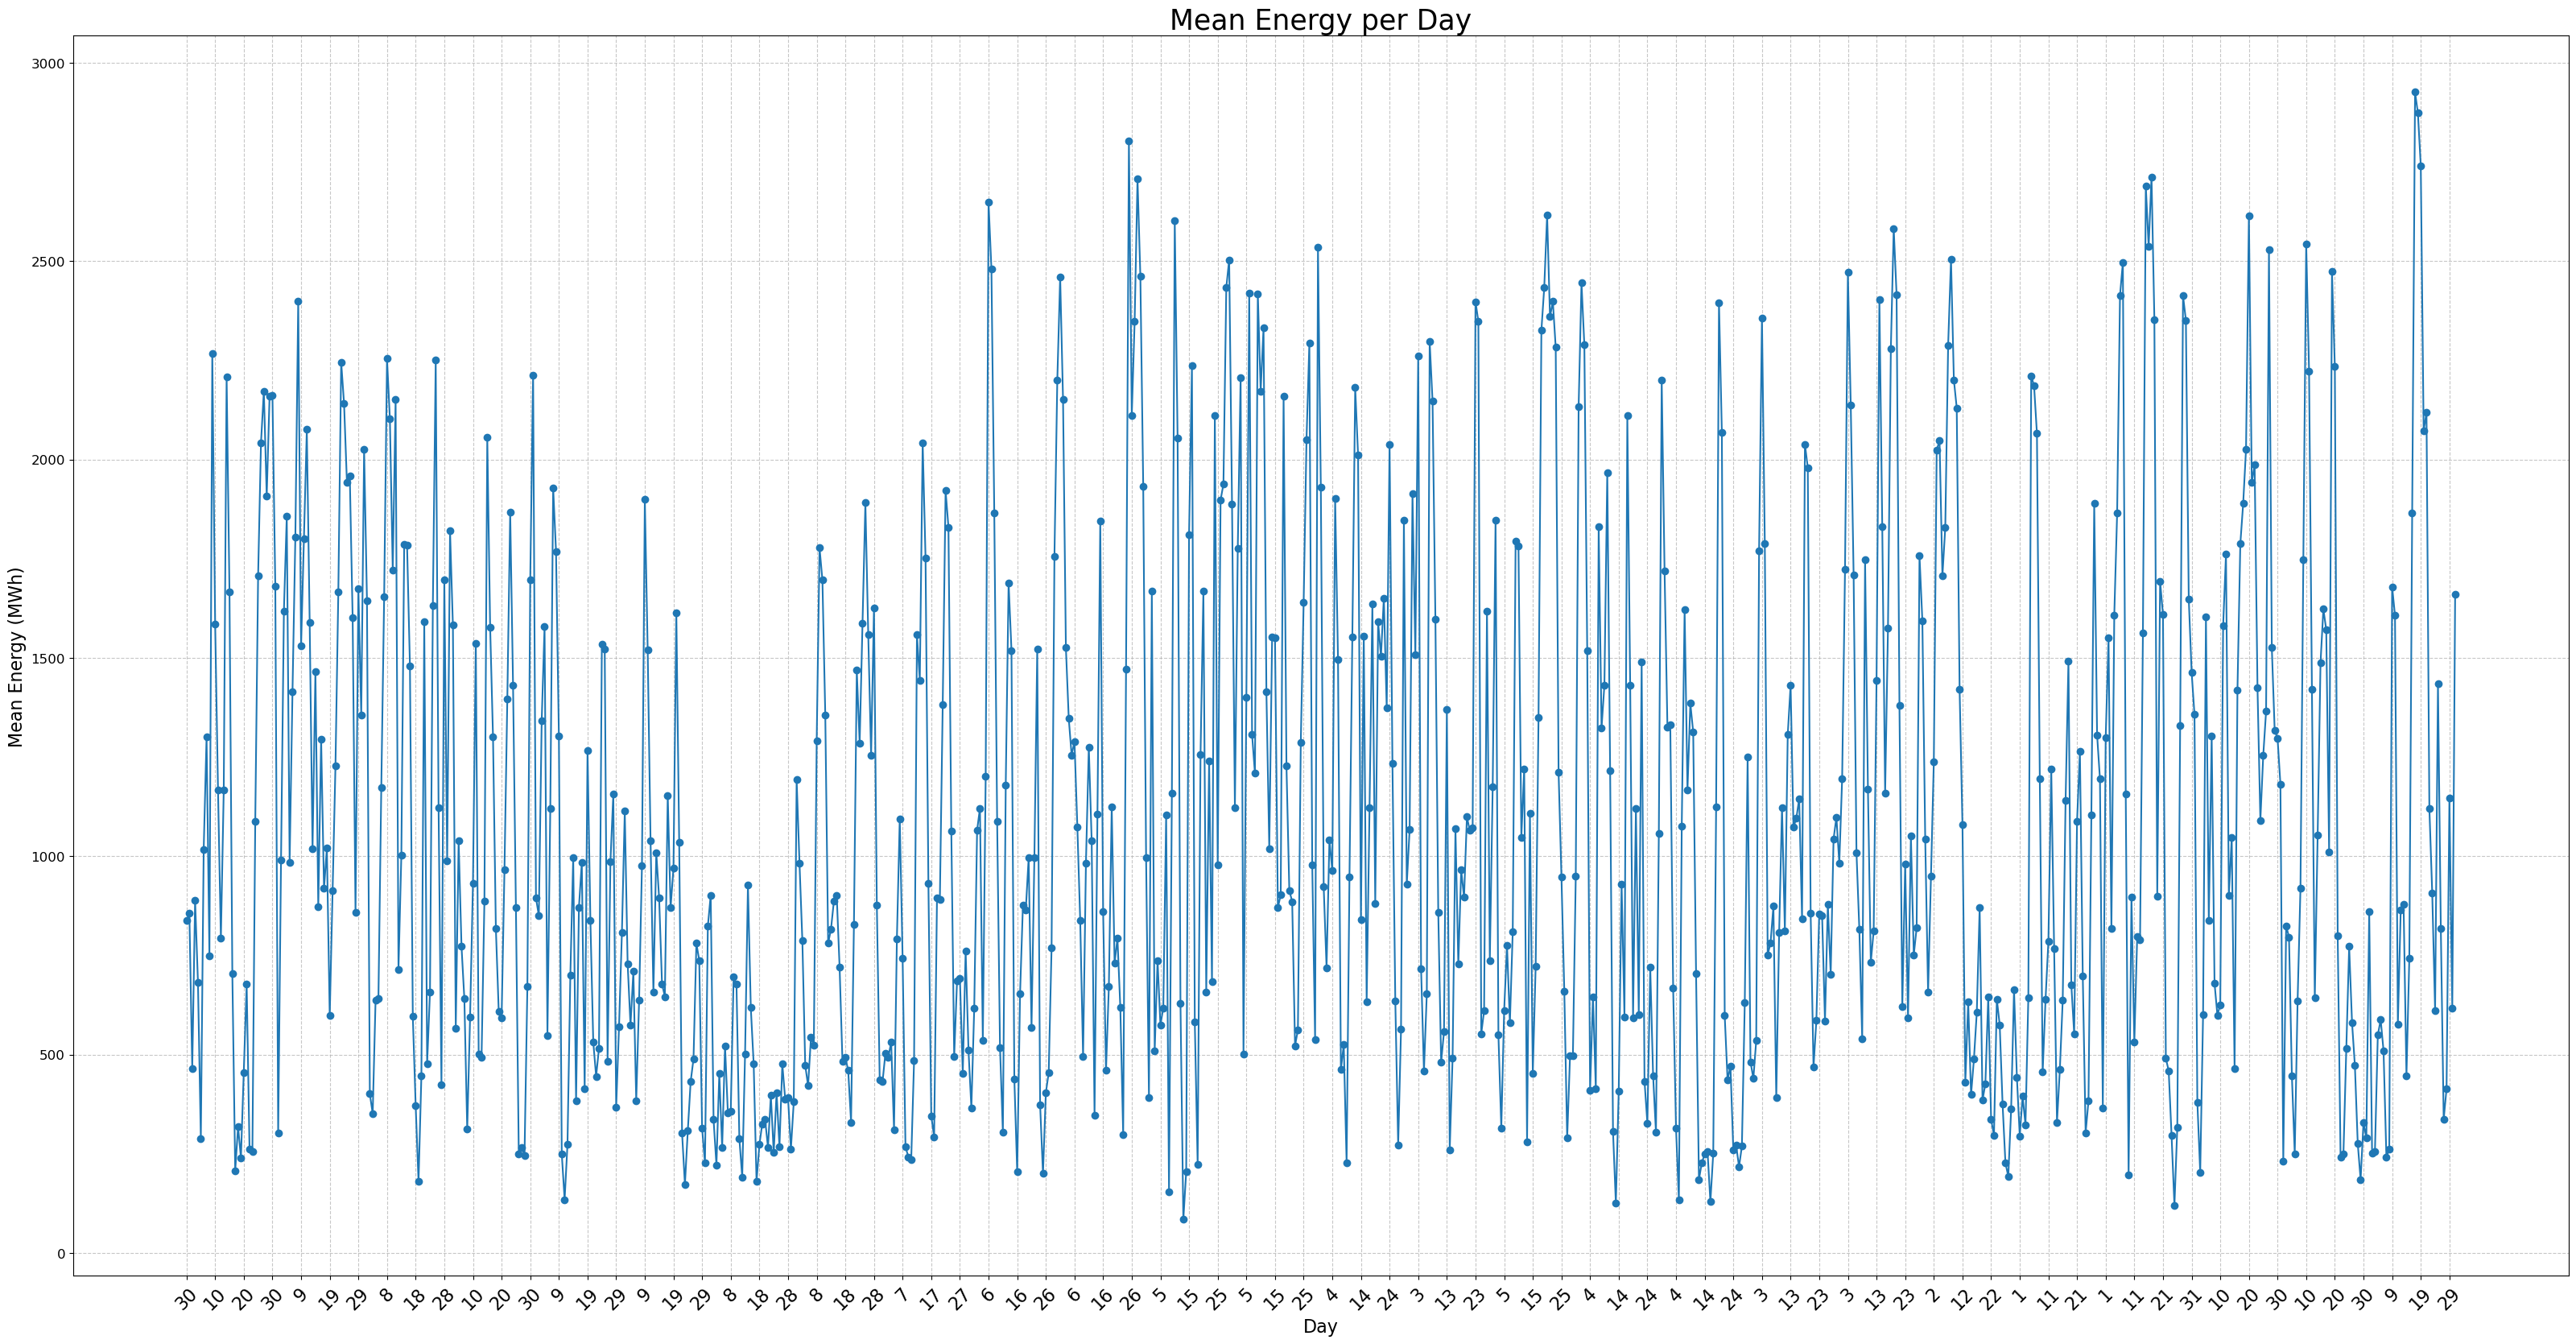

In [5]:
plt.figure(figsize=(40, 20))  
plt.plot(mean_energy_per_day.index, mean_energy_per_day['mean_energy_mwh'], marker='o')

# Adding titles and labels
plt.title('Mean Energy per Day', fontsize=25)
plt.xlabel('Day', fontsize=16)
plt.ylabel('Mean Energy (MWh)', fontsize=16)

# Set x-ticks to show every 5th imporve readability
ticks = mean_energy_per_day.index[::10]  # Take every 5th index
labels = mean_energy_per_day['day'].iloc[::10]  # Corresponding labels

plt.xticks(
    ticks=ticks,  # Positions for the ticks
    labels=labels,  # Labels for the ticks
    rotation=45,  # Rotate labels for better readability
    fontsize=16

)

plt.yticks(fontsize=12)

# Display grid for better readability
plt.grid(visible=True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()

Smoothen the curve by calculating the rolling average for every 25 entries 

In [6]:
rolling_group = mean_energy_per_day.rolling(window=30, step=1, min_periods=1).mean()
rolling_group

,year,month,day,mean_energy_mwh
0,2020.000000,11.000000,30.000000,837.333333
1,2020.000000,11.500000,15.500000,846.666667
2,2020.000000,11.666667,11.000000,719.597222
3,2020.000000,11.750000,9.000000,761.750000
4,2020.000000,11.800000,8.000000,745.766667
...,...,...,...,...
788,2022.900000,2.100000,15.600000,1031.227778
789,2022.933333,1.733333,15.566667,1038.872222
790,2022.966667,1.366667,15.533333,1066.134722
791,2023.000000,1.000000,15.500000,1077.068056


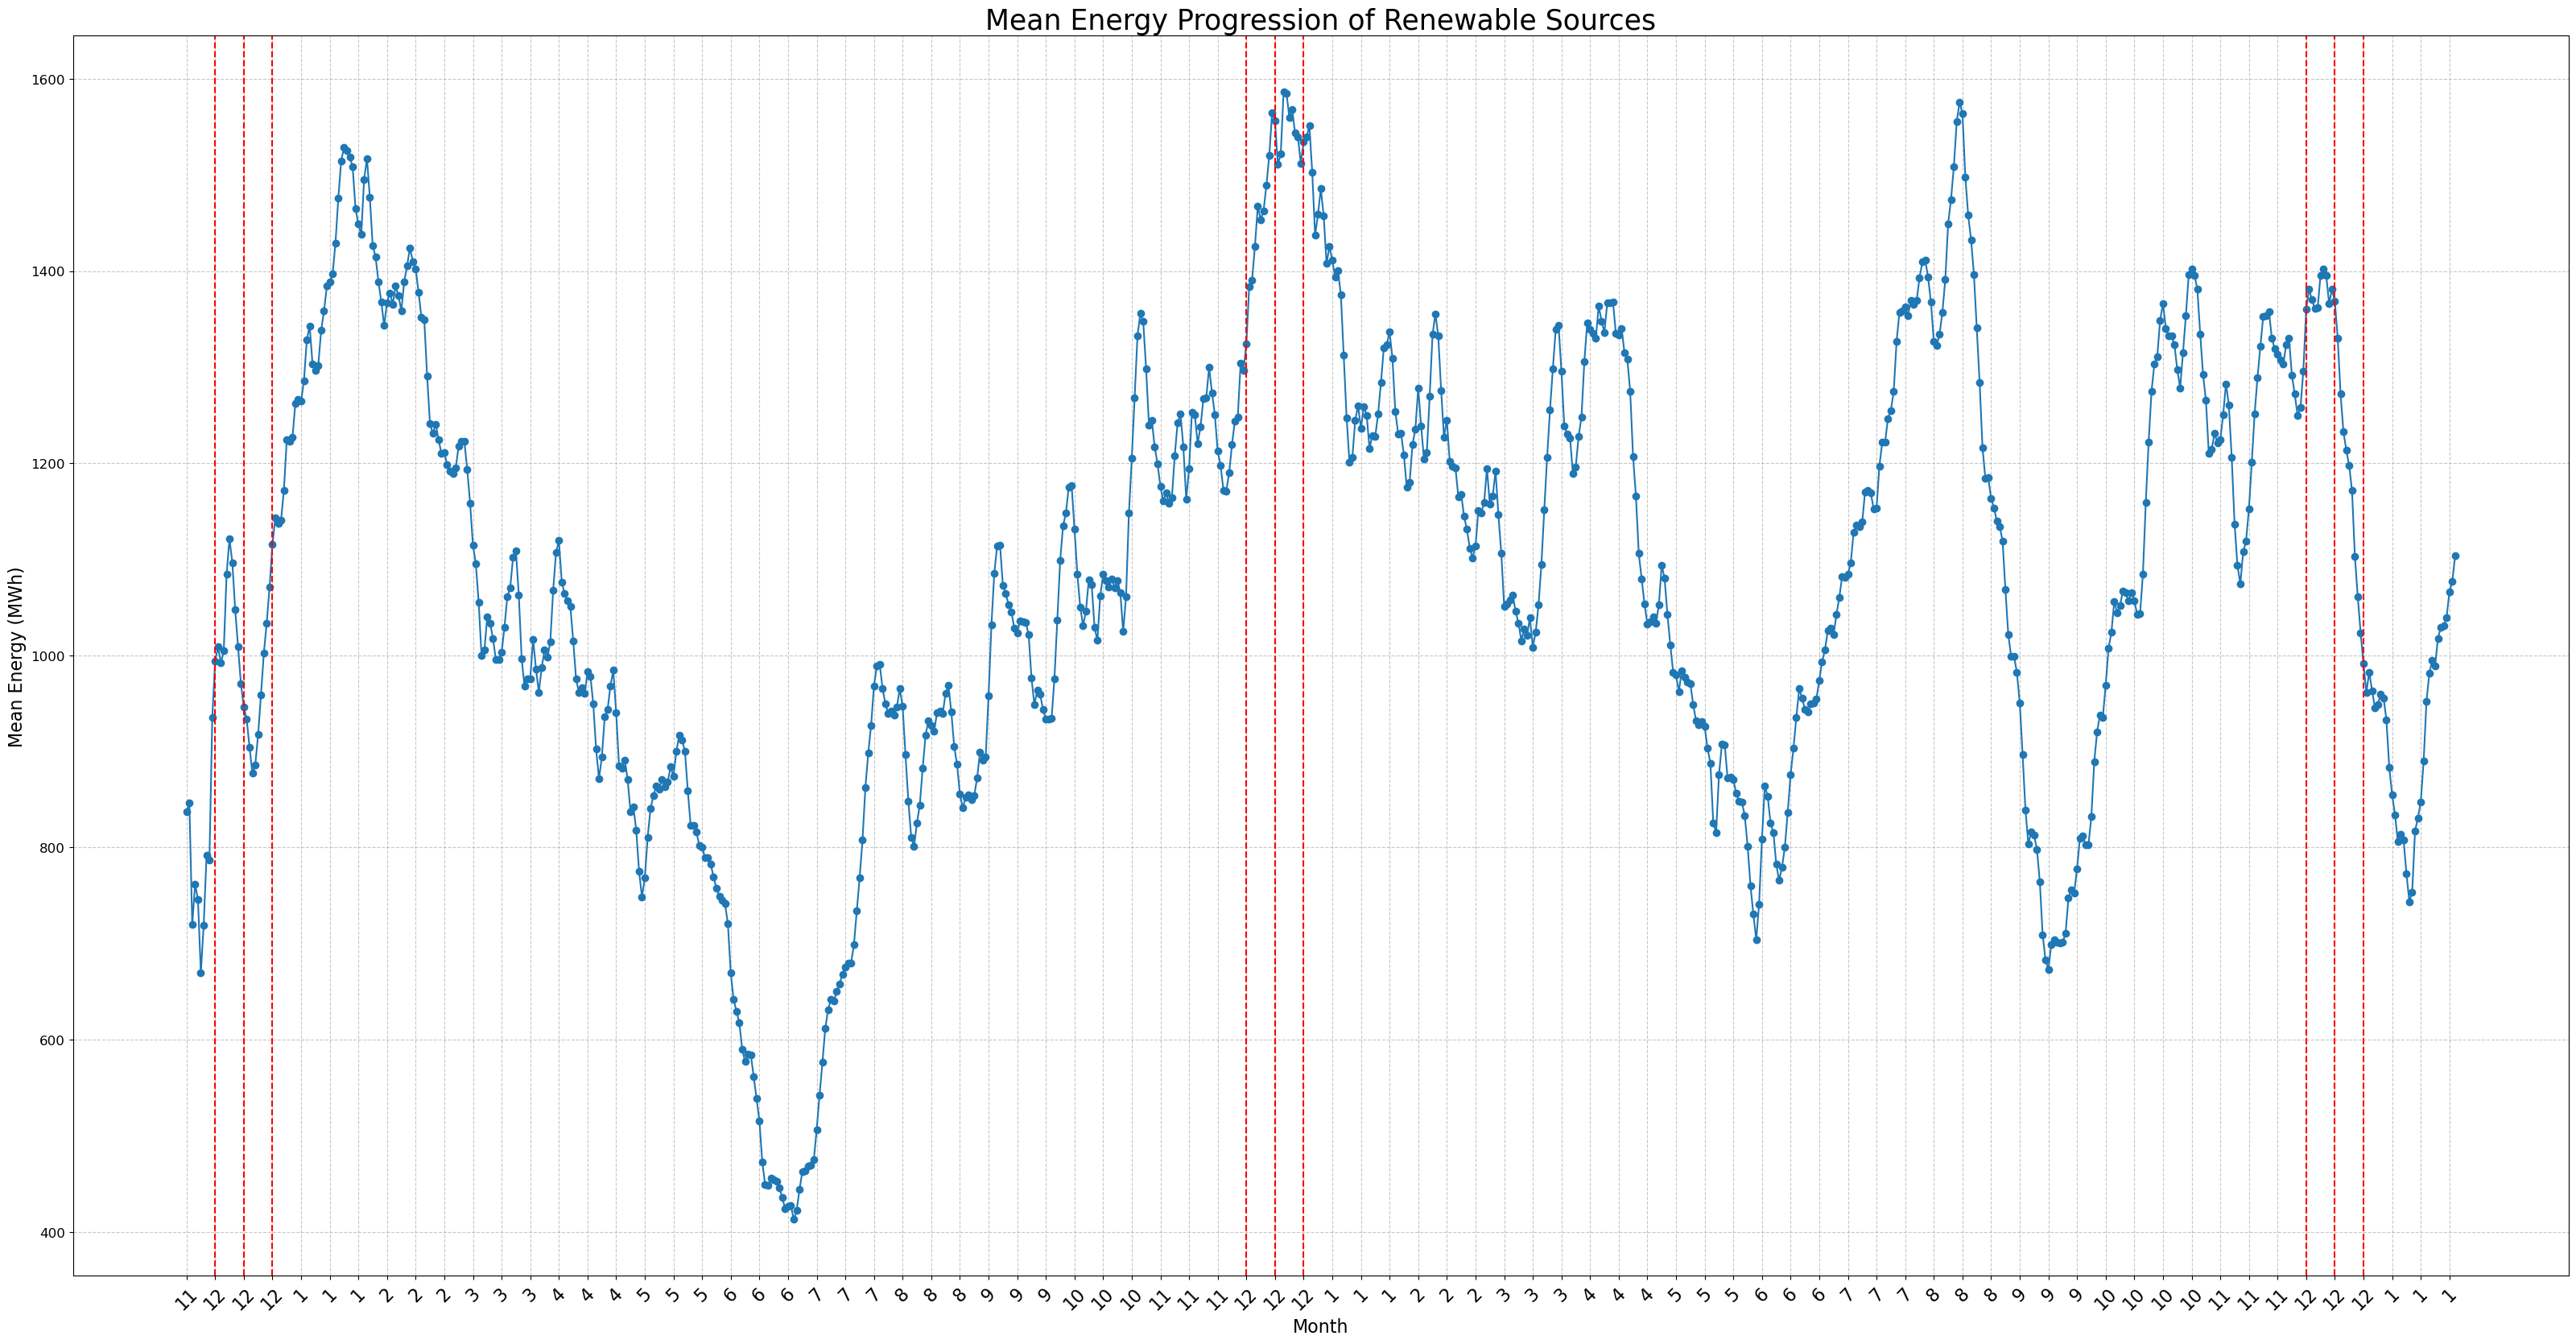

In [7]:
plt.figure(figsize=(40, 20))  # Adjust width and height as needed
plt.plot(rolling_group.index, rolling_group['mean_energy_mwh'], marker='o')

# Adding titles and labels
plt.title('Mean Energy Progression of Renewable Sources', fontsize=25)
plt.xlabel('Month', fontsize=16)
plt.ylabel('Mean Energy (MWh)', fontsize=16)

# Set x-ticks to show every 5th day
ticks = mean_energy_per_day.index[::10]  # Take every 10th index to avoind crouding the x-axis

labels = mean_energy_per_day['month'].iloc[::10]  # Corresponding labels

plt.xticks(
    ticks=ticks,  # Positions for the ticks
    labels=labels,  # Labels for the ticks
    rotation=45,  # Rotate labels for better readability
    fontsize=16
)

plt.yticks(fontsize=12)

# Draw vertical red lines for ticks with label '12'
for tick, label in zip(ticks, labels):
    if label == 12:
        plt.axvline(x=tick, color='red', linestyle='--', linewidth=1.5)

# Display grid for better readability
plt.grid(visible=True, linestyle='--', alpha=0.7)

plt.savefig('../outputs/graphs/energy/mean_energy_progression_rolling_30.png')
# Show the plot
plt.show()


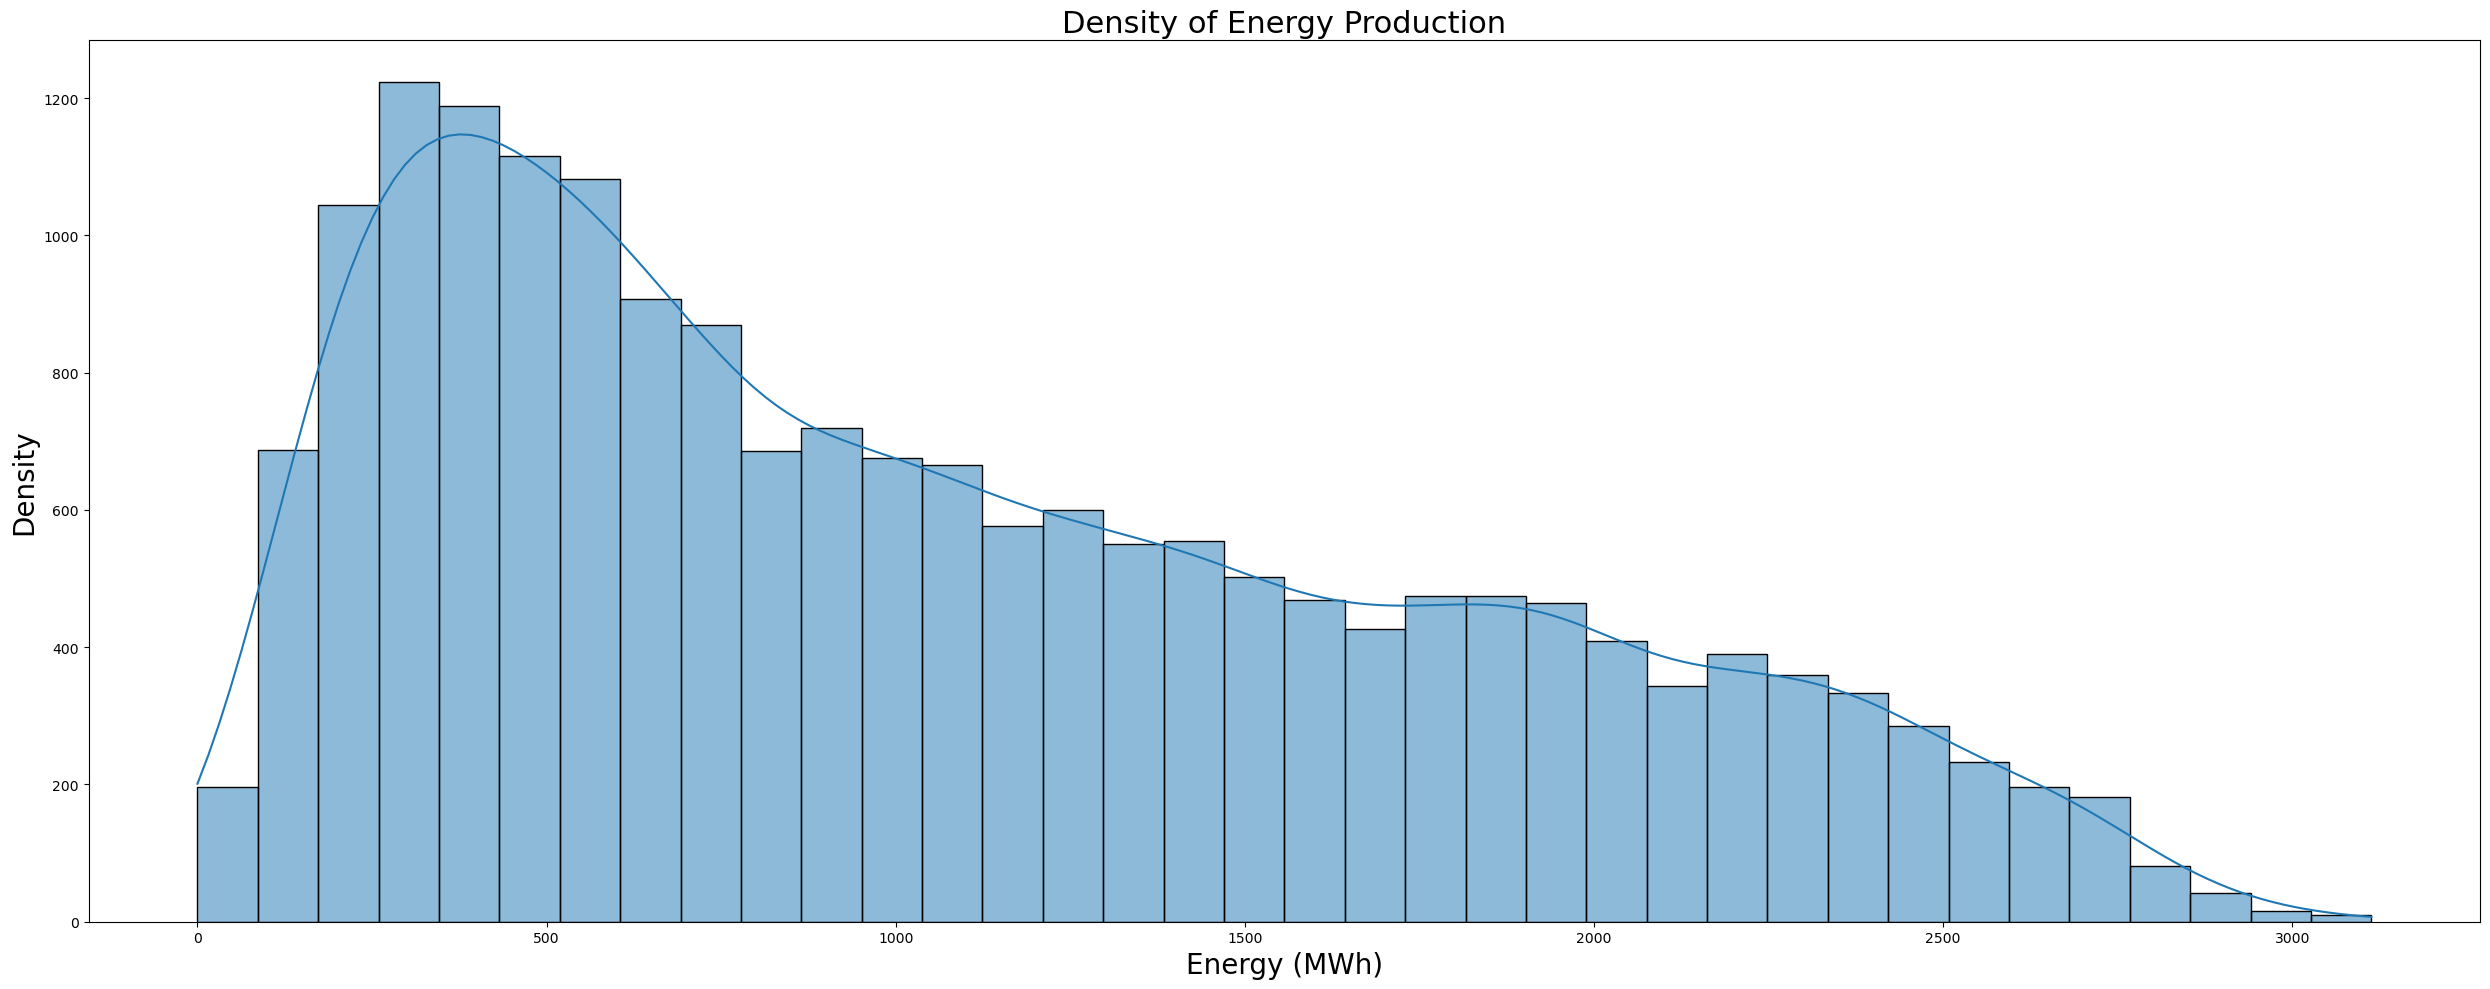

In [8]:
plt.figure(figsize=(25,10))
sns.histplot(renewable['energy_mwh'], fill=True, kde=True)

plt.title('Density of Energy Production')
plt.xlabel('Energy (MWh)')

plt.title('Density of Energy Production', fontsize=22)
plt.ylabel('Density', fontsize=20)
plt.xlabel('Energy (MWh)', fontsize=20)

plt.tight_layout()

plt.savefig('../outputs/graphs/energy/density_energy_hist.png')
plt.show()

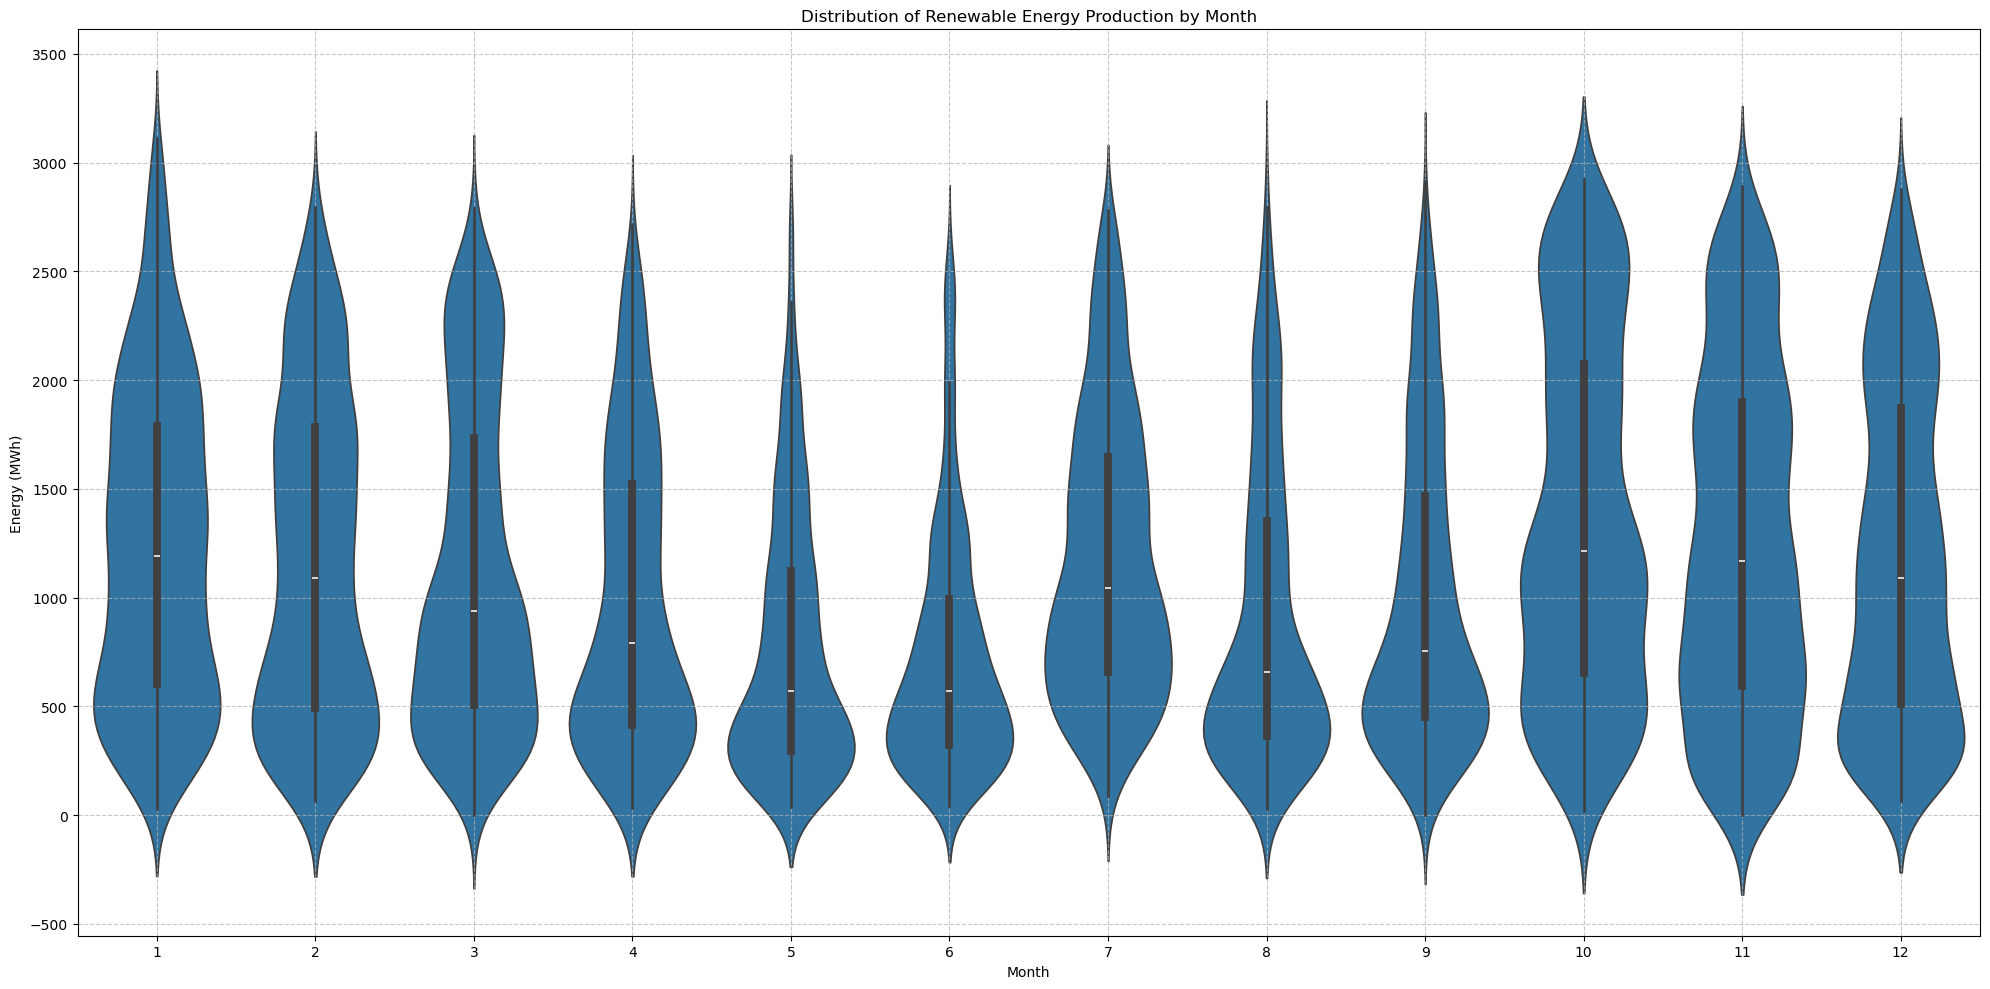

In [9]:
plt.figure(figsize=(20,10))
sns.violinplot(x='month', y='energy_mwh', data=renewable, density_norm='width')
plt.title('Distribution of Renewable Energy Production by Month')
plt.xlabel('Month')
plt.ylabel('Energy (MWh)')

plt.grid(visible=True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('../outputs/graphs/energy/energy_violin.png')

plt.show()

A violin plot whows us the drop of energy production during Spring months and the increase during Winter

Now let's examine the enrgy production from various other sources 

In [6]:
energy = pd.read_csv('../data/daily_energy_balance.csv', date_parser='date')
energy

/tmp/ipykernel_36712/3750099938.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  energy = pd.read_csv('../data/daily_energy_balance.csv', date_parser='date')


,date,energy_mwh,fuel,percentage
0,2020-11-30 19:00:00,69816,ΑΕΡΙΟ,0.489000
1,2020-11-30 19:00:00,25423,ΑΙΟΛΙΚΑ,0.178000
2,2020-11-30 19:00:00,-2280,ΚΑΘΑΡΕΣ ΕΙΣΑΓΩΓΕΣ (ΕΙΣΑΓΩΓΕΣ-ΕΞΑΓΩΓΕΣ),-0.010000
3,2020-11-30 19:00:00,36927,ΛΙΓΝΙΤΗΣ,0.258000
4,2020-11-30 19:00:00,142704,ΣΥΝΟΛΟ,1.004000
...,...,...,...,...
6655,2023-12-30 00:00:00,11620,ΑΠΕ,0.102536
6656,2023-12-30 00:00:00,31574,ΚΑΘΑΡΕΣ ΕΙΣΑΓΩΓΕΣ (ΕΙΣΑΓΩΓΕΣ-ΕΞΑΓΩΓΕΣ),0.278612
6657,2023-12-30 00:00:00,13818,ΛΙΓΝΙΤΗΣ,0.121931
6658,2023-12-30 00:00:00,113326,ΣΥΝΟΛΟ,1.000000


In [7]:
rename_dict = {
    'ΑΕΡΙΟ': 'Gas',
    'ΑΙΟΛΙΚΑ': 'Wind',
    'ΚΑΘΑΡΕΣ ΕΙΣΑΓΩΓΕΣ (ΕΙΣΑΓΩΓΕΣ-ΕΞΑΓΩΓΕΣ)': 'Net Imports (Imports - Exports)',
    'ΛΙΓΝΙΤΗΣ': 'Lignite',
    'ΣΥΝΟΛΟ': 'Total',
    'ΥΔΡΟΗΛΕΚΤΡΙΚΑ': 'Hydroelectric',
    'ΦΥΣΙΚΟ ΑΕΡΙΟ': 'Natural Gas',
    'ΑΠΕ': 'RES (Renewable Energy Sources)',
    'ΣΥΝΟΛΟ': 'Total'
}

energy['fuel'] = energy['fuel'].map(rename_dict)

In [8]:
energy['year'] = pd.to_datetime(energy['date']).dt.year
energy['month'] = pd.to_datetime(energy['date']).dt.month
energy['day'] = pd.to_datetime(energy['date']).dt.day

In [9]:
def calculate_absolute_values(row):
    return row['percentage'] * row['energy_mwh']


energy['absolute_energy_mwh'] = energy.apply(calculate_absolute_values, axis=1)

pivot_table = energy.pivot_table(
    index=['year', 'month', 'day'],  
    columns='fuel',                 
    values=['energy_mwh'],           
    aggfunc='sum',
    fill_value=0 # Fill NaN values with 0. This serves consistency of data types as certain entries are not registered at all times
)

# Reset the index to make it more readable (optional)
pivot_table.reset_index(inplace=True)

# Optional: Rename the index column names for clarity
pivot_table.columns.name = None  # Remove the name for the columns
pivot_table.rename(columns={"year": "Year", "month": "Month", "day": "Day"}, inplace=True)


In [10]:
pivot_table.columns = ['_'.join(filter(None, col)) for col in pivot_table.columns]
pivot_table

,Year,Month,Day,energy_mwh_Gas,energy_mwh_Hydroelectric,energy_mwh_Lignite,energy_mwh_Natural Gas,energy_mwh_Net Imports (Imports - Exports),energy_mwh_RES (Renewable Energy Sources),energy_mwh_Total,energy_mwh_Wind
0,2020,11,30,69816,12818,36927,0,-2280,0,142704,25423
1,2020,12,1,66126,18387,38536,0,9736,0,143824,11039
2,2020,12,2,59065,12454,40669,0,10327,0,141005,18490
3,2020,12,3,59030,7111,35770,0,14607,0,137215,20697
4,2020,12,4,59139,3812,32534,0,25489,0,126359,5385
...,...,...,...,...,...,...,...,...,...,...,...
1100,2023,12,26,23742,11917,8006,0,23745,25667,93077,0
1101,2023,12,27,32921,12672,12285,0,27957,17444,103279,0
1102,2023,12,28,32979,15967,15443,0,31606,10070,106065,0
1103,2023,12,29,31317,14363,19223,0,25885,17640,108428,0


In [11]:
# Dictionary to translate data columns for easier handling and readability

rename_dict = {
    'Year': 'year',
    'Month': 'month',
    'Day': 'day',
    'energy_mwh_Gas': 'gas',
    'energy_mwh_Hydroelectric': 'hydroelectric',
    'energy_mwh_Lignite': 'lignite',
    'energy_mwh_Natural Gas': 'natural_gas',
    'energy_mwh_Net Imports (Imports - Exports)': 'net_imports',
    'energy_mwh_RES (Renewable Energy Sources)': 'renewables',
    'energy_mwh_Total': 'total',
    'energy_mwh_Wind': 'wind'
}



pivot_table.rename(columns=rename_dict, inplace=True)

In [12]:
rolling_table = pivot_table.rolling(window=30, step=1, min_periods=1).mean()

In [13]:
rolling_table[['year', 'month', 'day']] = rolling_table[['year', 'month', 'day']].astype(dtype=int, copy=True) # Fix data types

rolling_table

,year,month,day,gas,hydroelectric,lignite,natural_gas,net_imports,renewables,total,wind
0,2020,11,30,69816.000000,12818.000000,36927.000000,0.0,-2280.000000,0.000000,142704.000000,25423.000000
1,2020,11,15,67971.000000,15602.500000,37731.500000,0.0,3728.000000,0.000000,143264.000000,18231.000000
2,2020,11,11,65002.333333,14553.000000,38710.666667,0.0,5927.666667,0.000000,142511.000000,18317.333333
3,2020,11,9,63509.250000,12692.500000,37975.500000,0.0,8097.500000,0.000000,141187.000000,18912.250000
4,2020,11,8,62635.200000,10916.400000,36887.200000,0.0,11575.800000,0.000000,138221.400000,16206.800000
...,...,...,...,...,...,...,...,...,...,...,...
1100,2023,11,15,47934.966667,19620.033333,19339.900000,0.0,5948.533333,42695.333333,137856.600000,2317.833333
1101,2023,11,15,47596.633333,19542.133333,19041.500000,0.0,7143.566667,41224.300000,136865.966667,2317.833333
1102,2023,11,15,47175.000000,19523.033333,18890.100000,0.0,8840.066667,39779.466667,136525.500000,2317.833333
1103,2023,11,15,46316.666667,19346.933333,18880.266667,0.0,10214.266667,39415.533333,136491.500000,2317.833333


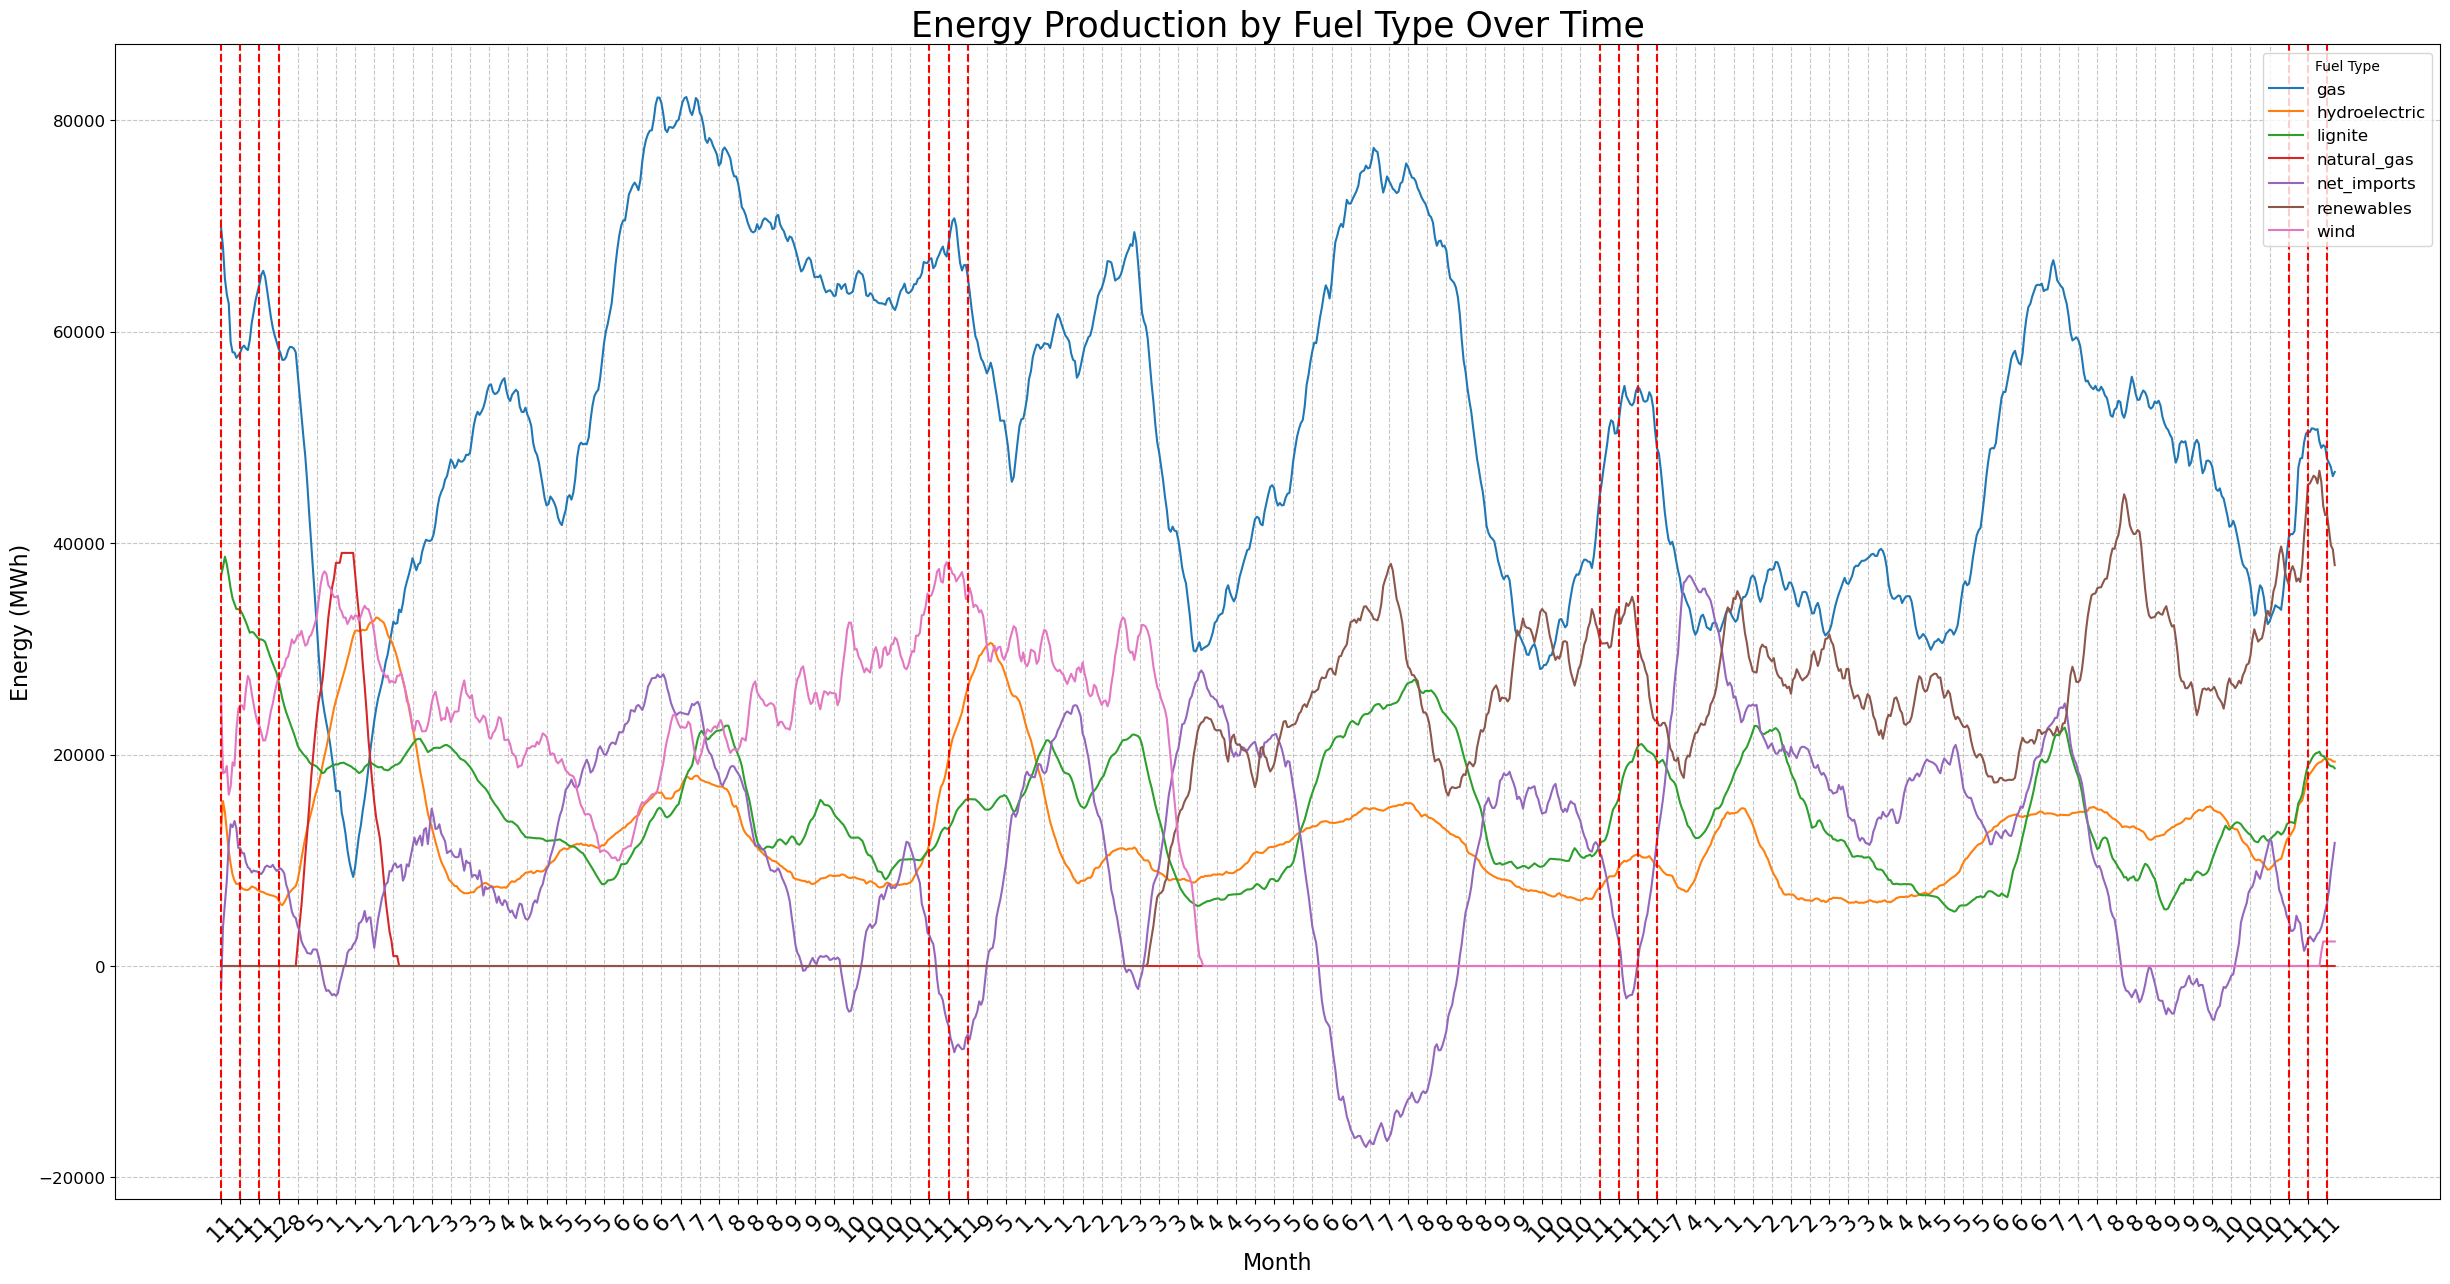

In [14]:
fuel_columns = ['gas', 'hydroelectric', 'lignite', 'natural_gas', 
                'net_imports', 'renewables', 'wind']

plt.figure(figsize=(30, 15))

# Plot each fuel type
for fuel in fuel_columns:
    plt.plot(
        range(len(rolling_table)), 
        rolling_table[fuel],    
        label=fuel          
    )

ticks = rolling_table.index[::10]  # Take every 10th index to avoind crouding the x-axis

labels = rolling_table['month'].iloc[::10]  # Corresponding labels

plt.xticks(
    ticks=ticks,  
    labels=labels,  
    rotation=45,  # Rotate labels for better readability
    fontsize=16
)

plt.yticks(fontsize=12)

# Draw vertical red lines for ticks with label '12'
for tick, label in zip(ticks, labels):
    if label == 12 or label == 11:
        plt.axvline(x=tick, color='red', linestyle='--', linewidth=1.5)

        
plt.title('Energy Production by Fuel Type Over Time', fontsize=25)
plt.xlabel('Month', fontsize=16)
plt.ylabel('Energy (MWh)', fontsize=16)

plt.legend(title='Fuel Type', fontsize=12)

plt.grid(visible=True, linestyle='--', alpha=0.7)
plt.savefig('../outputs/graphs/energy/energy_sources_progression.png', dpi=300)
plt.show()

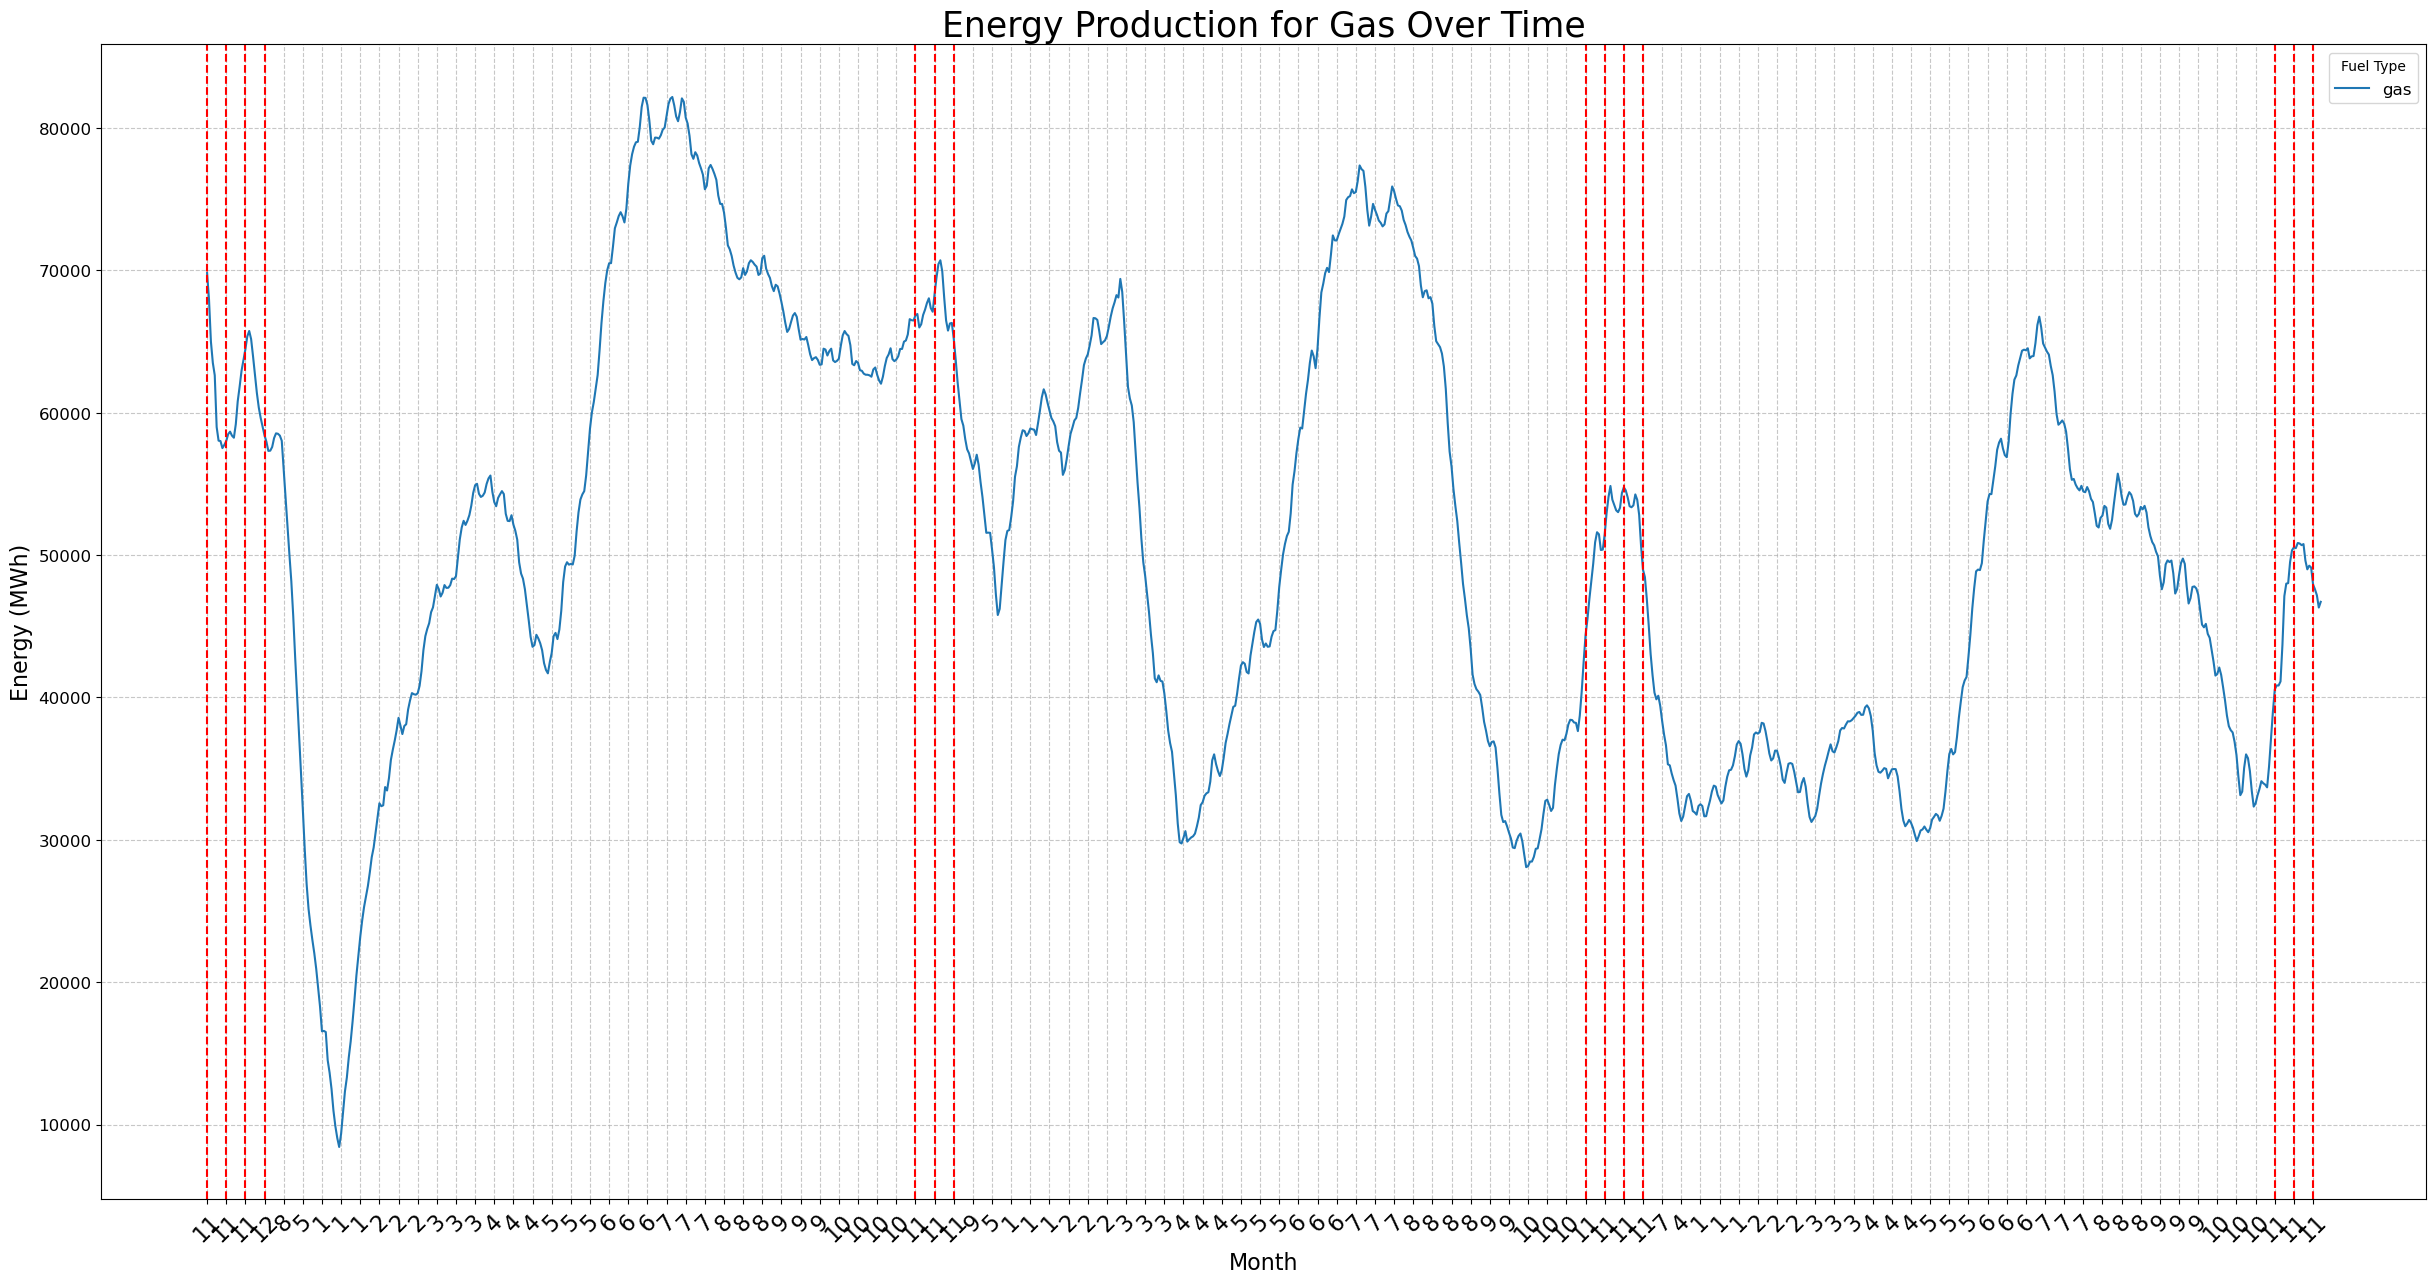

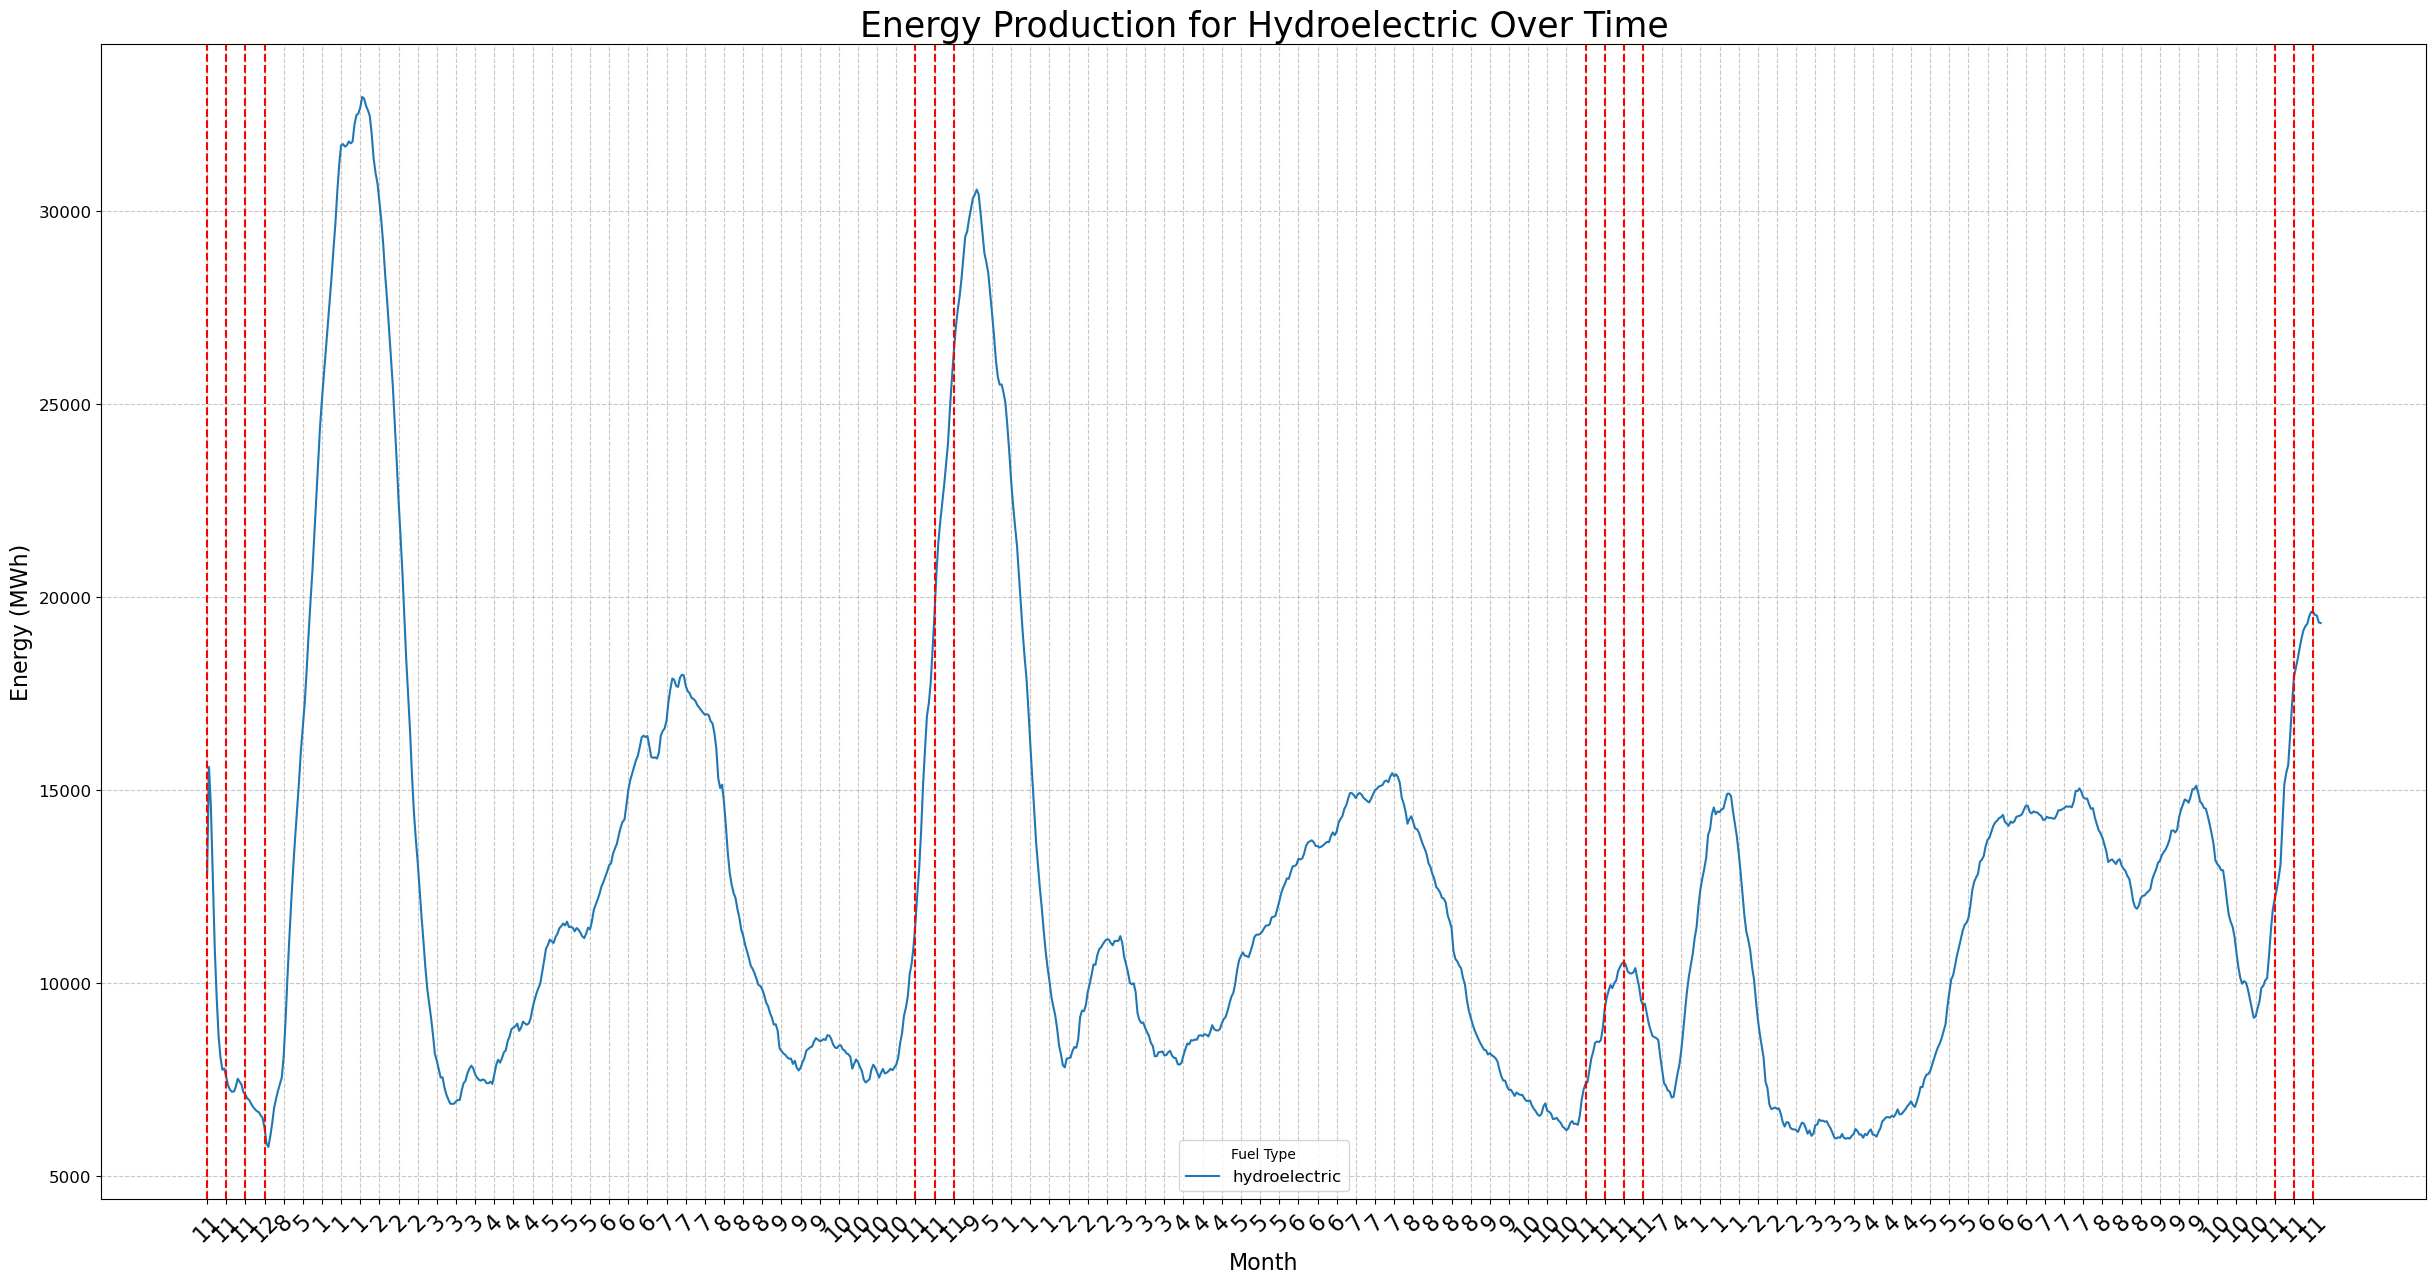

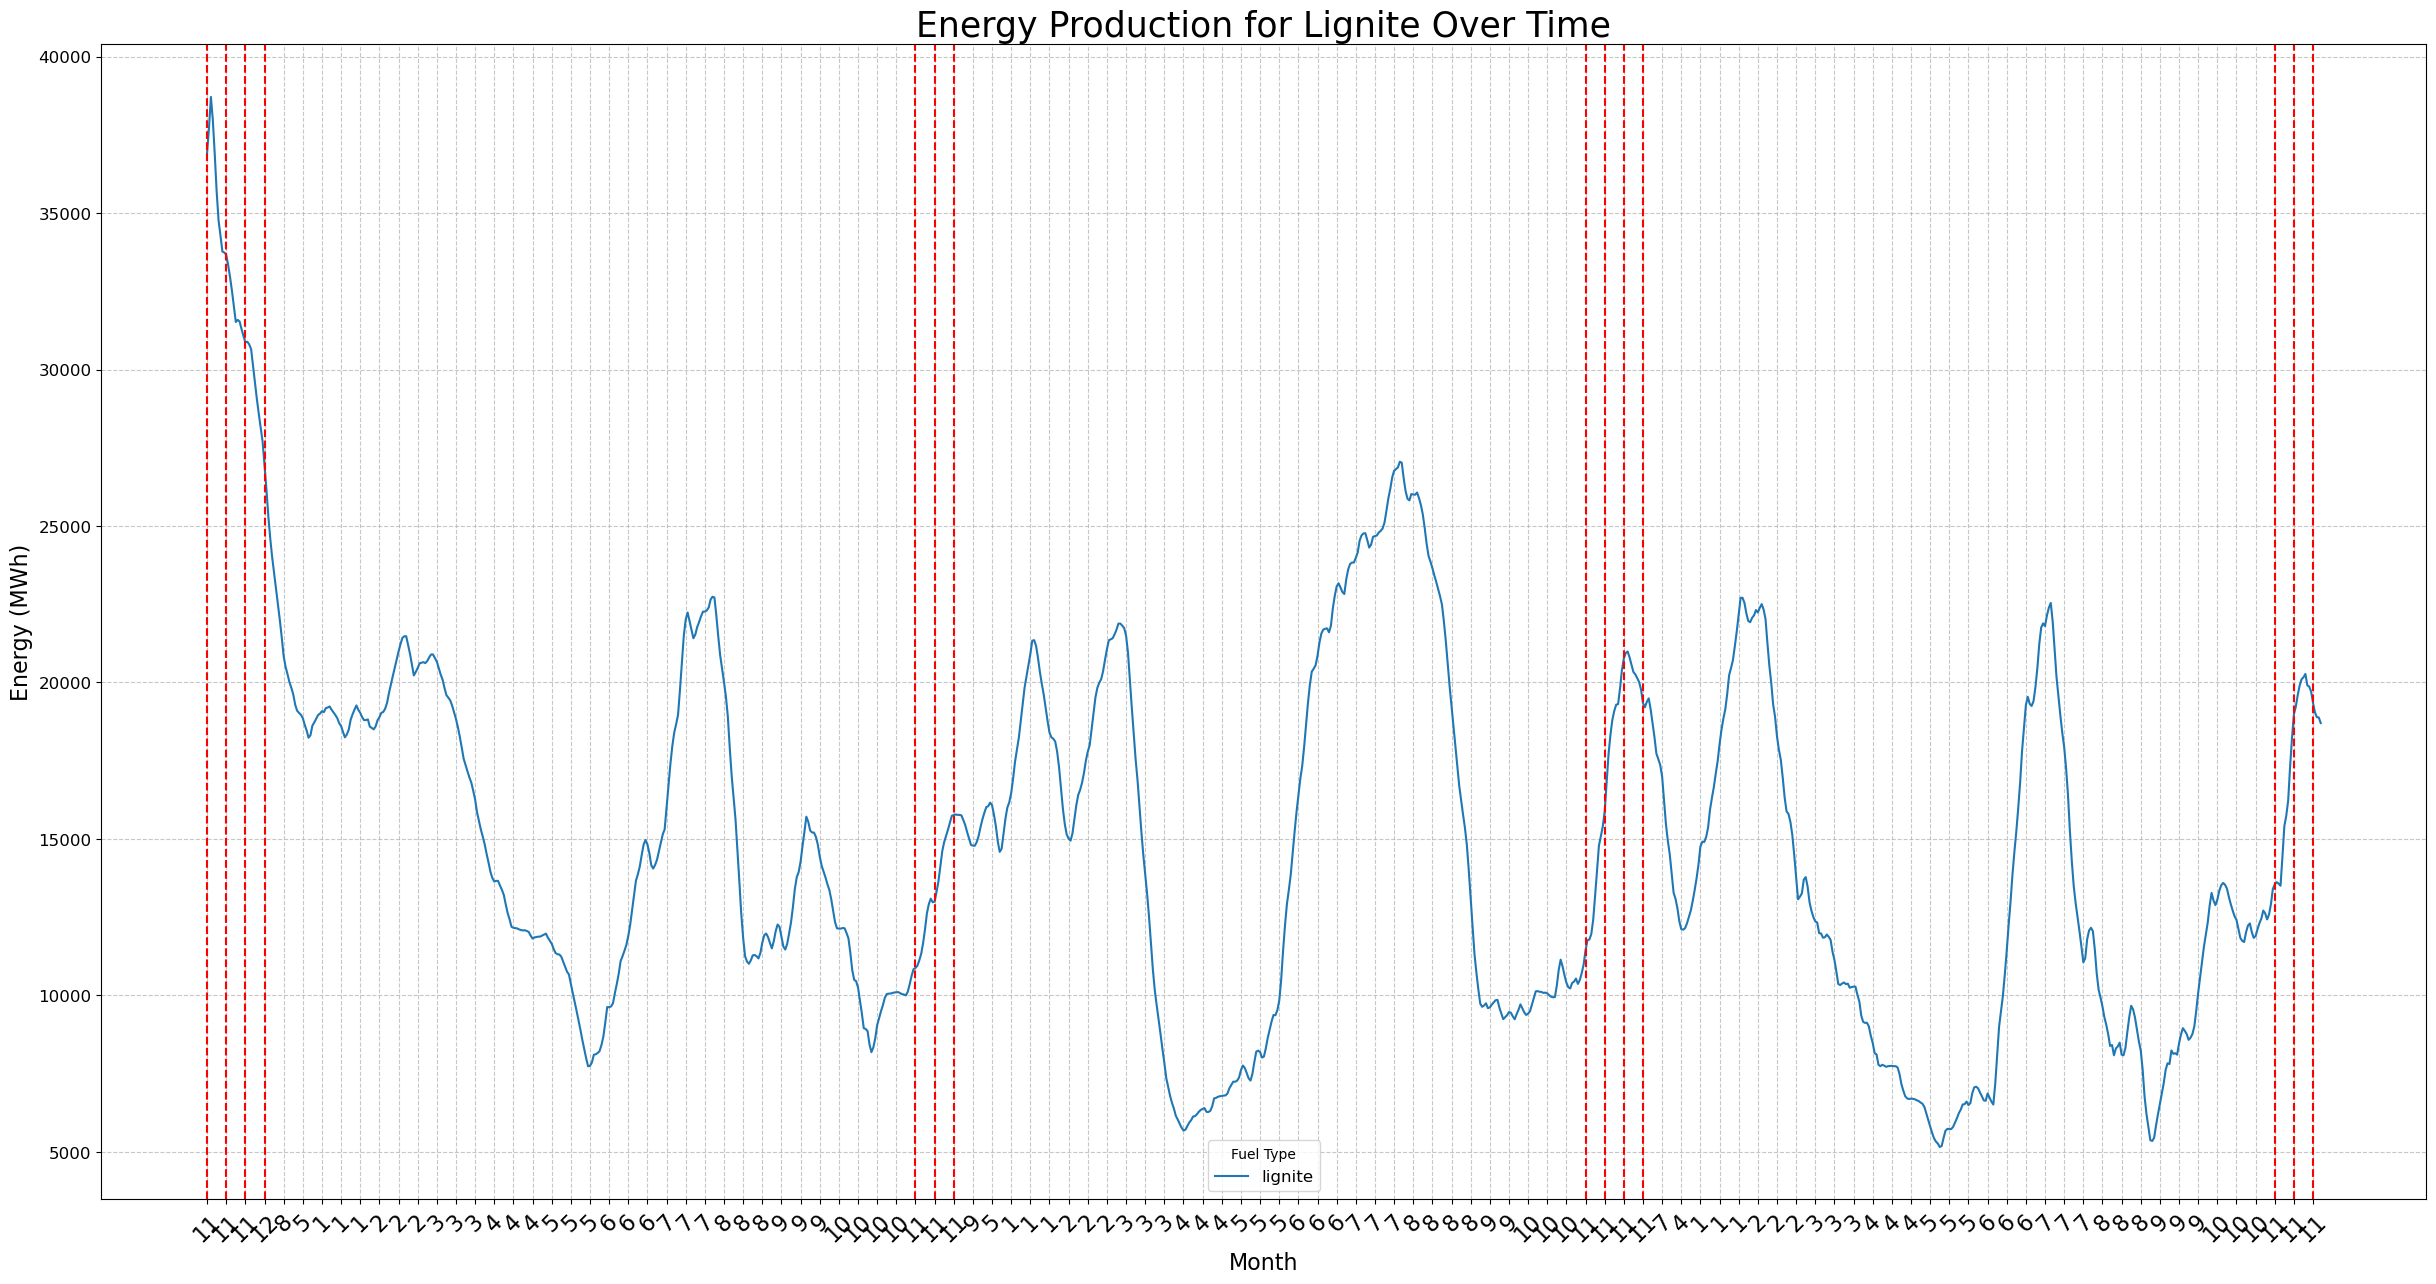

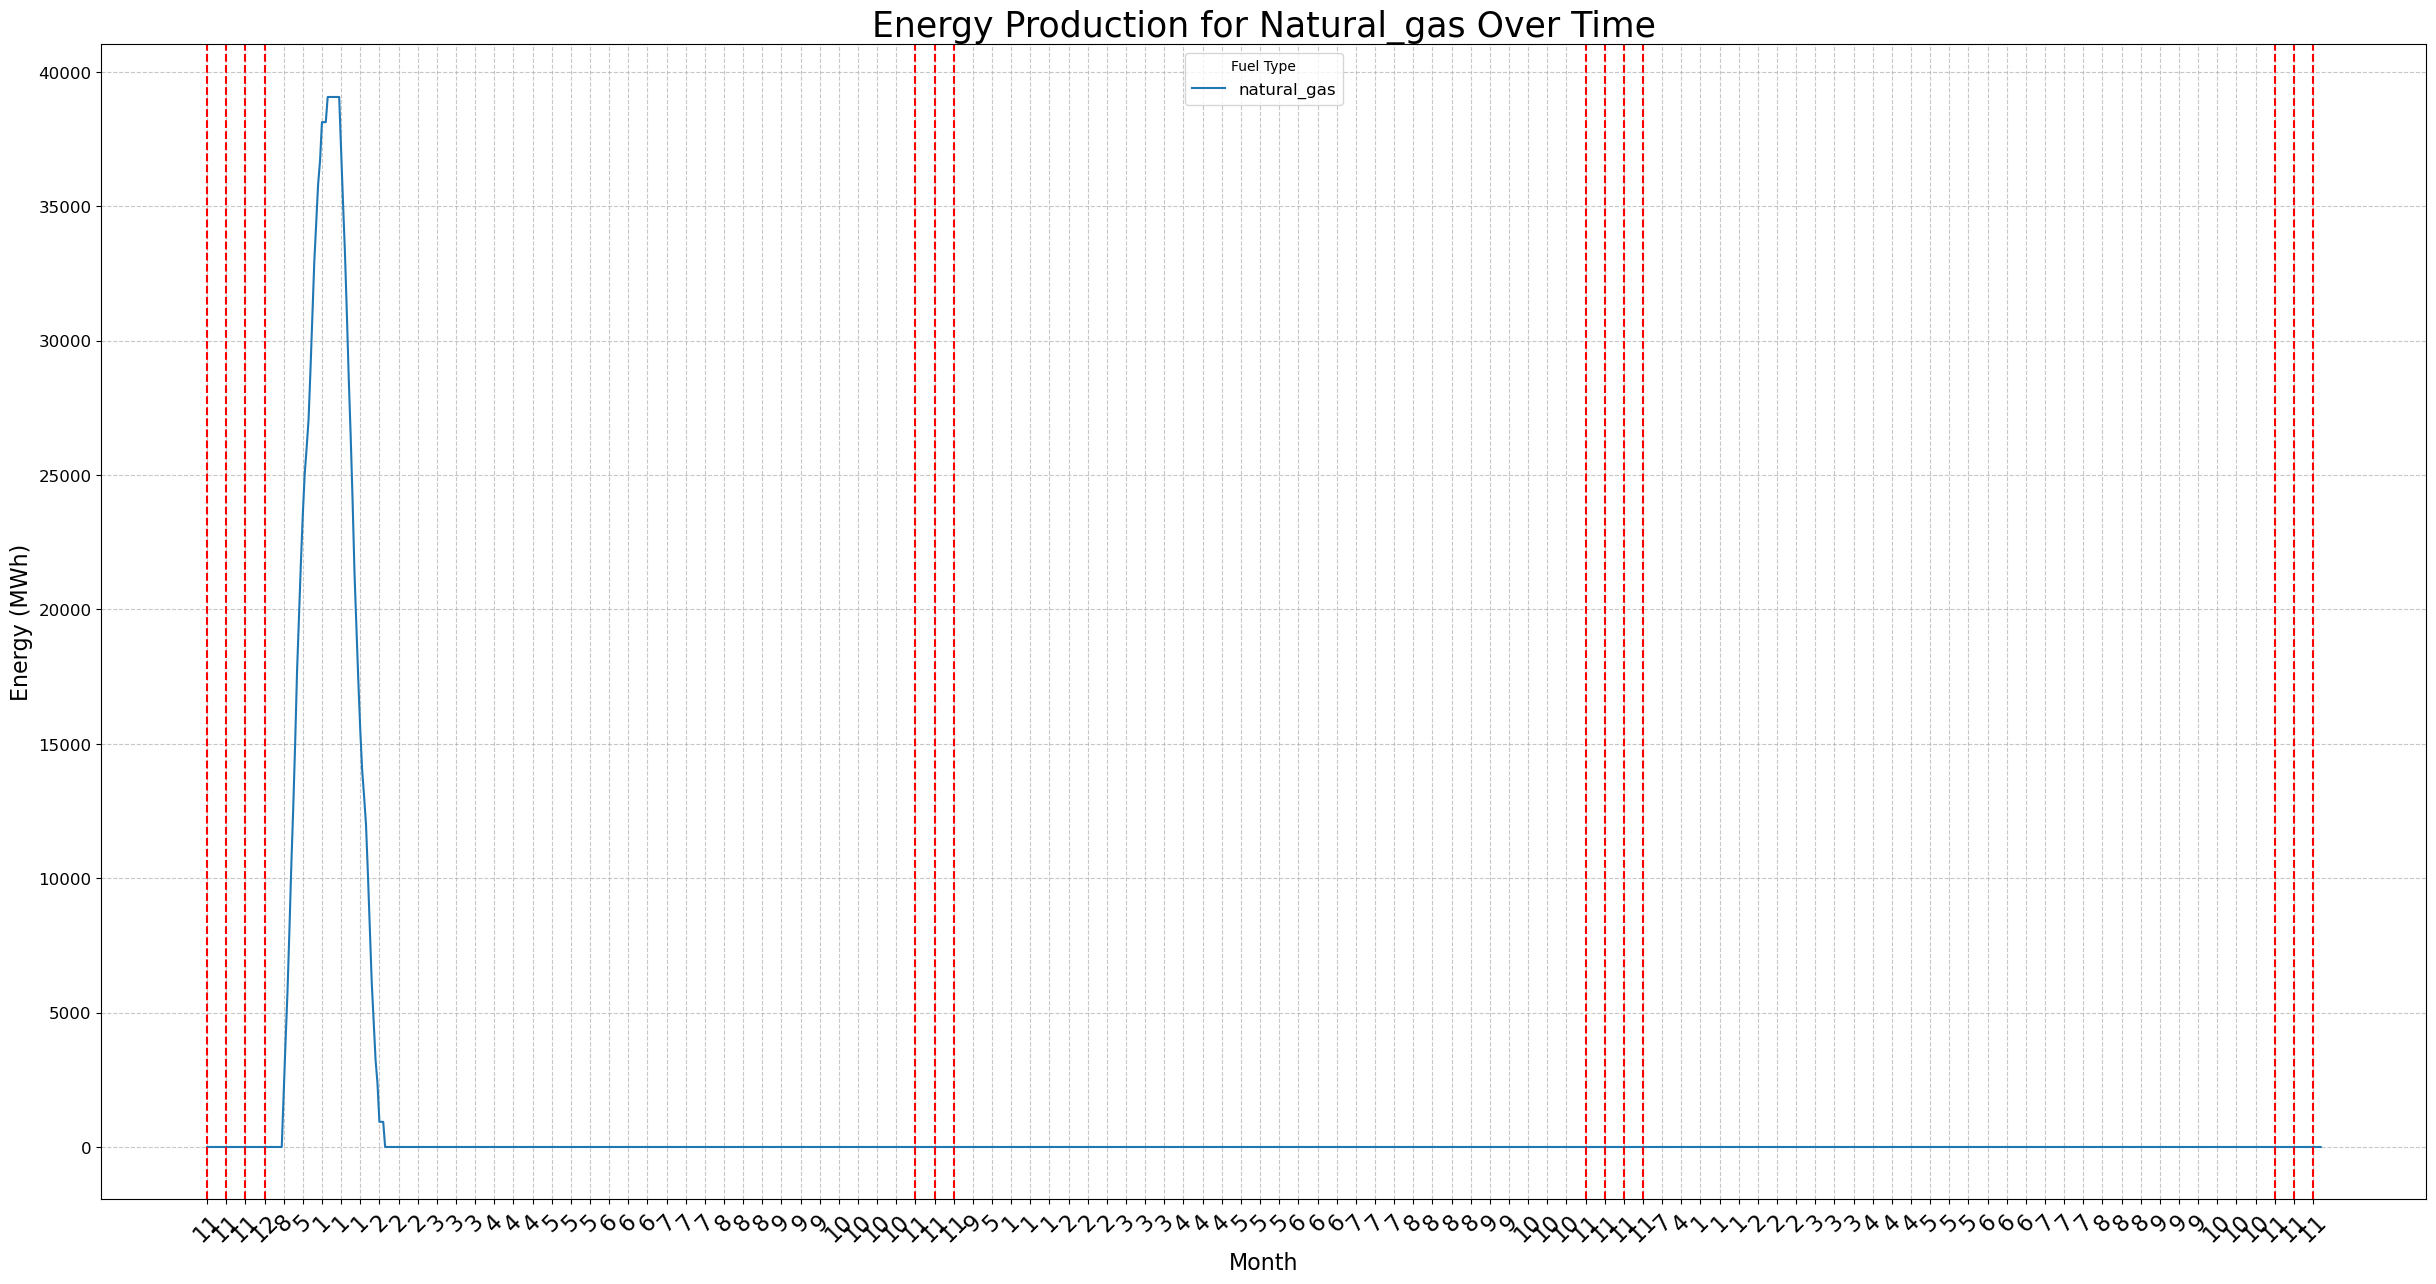

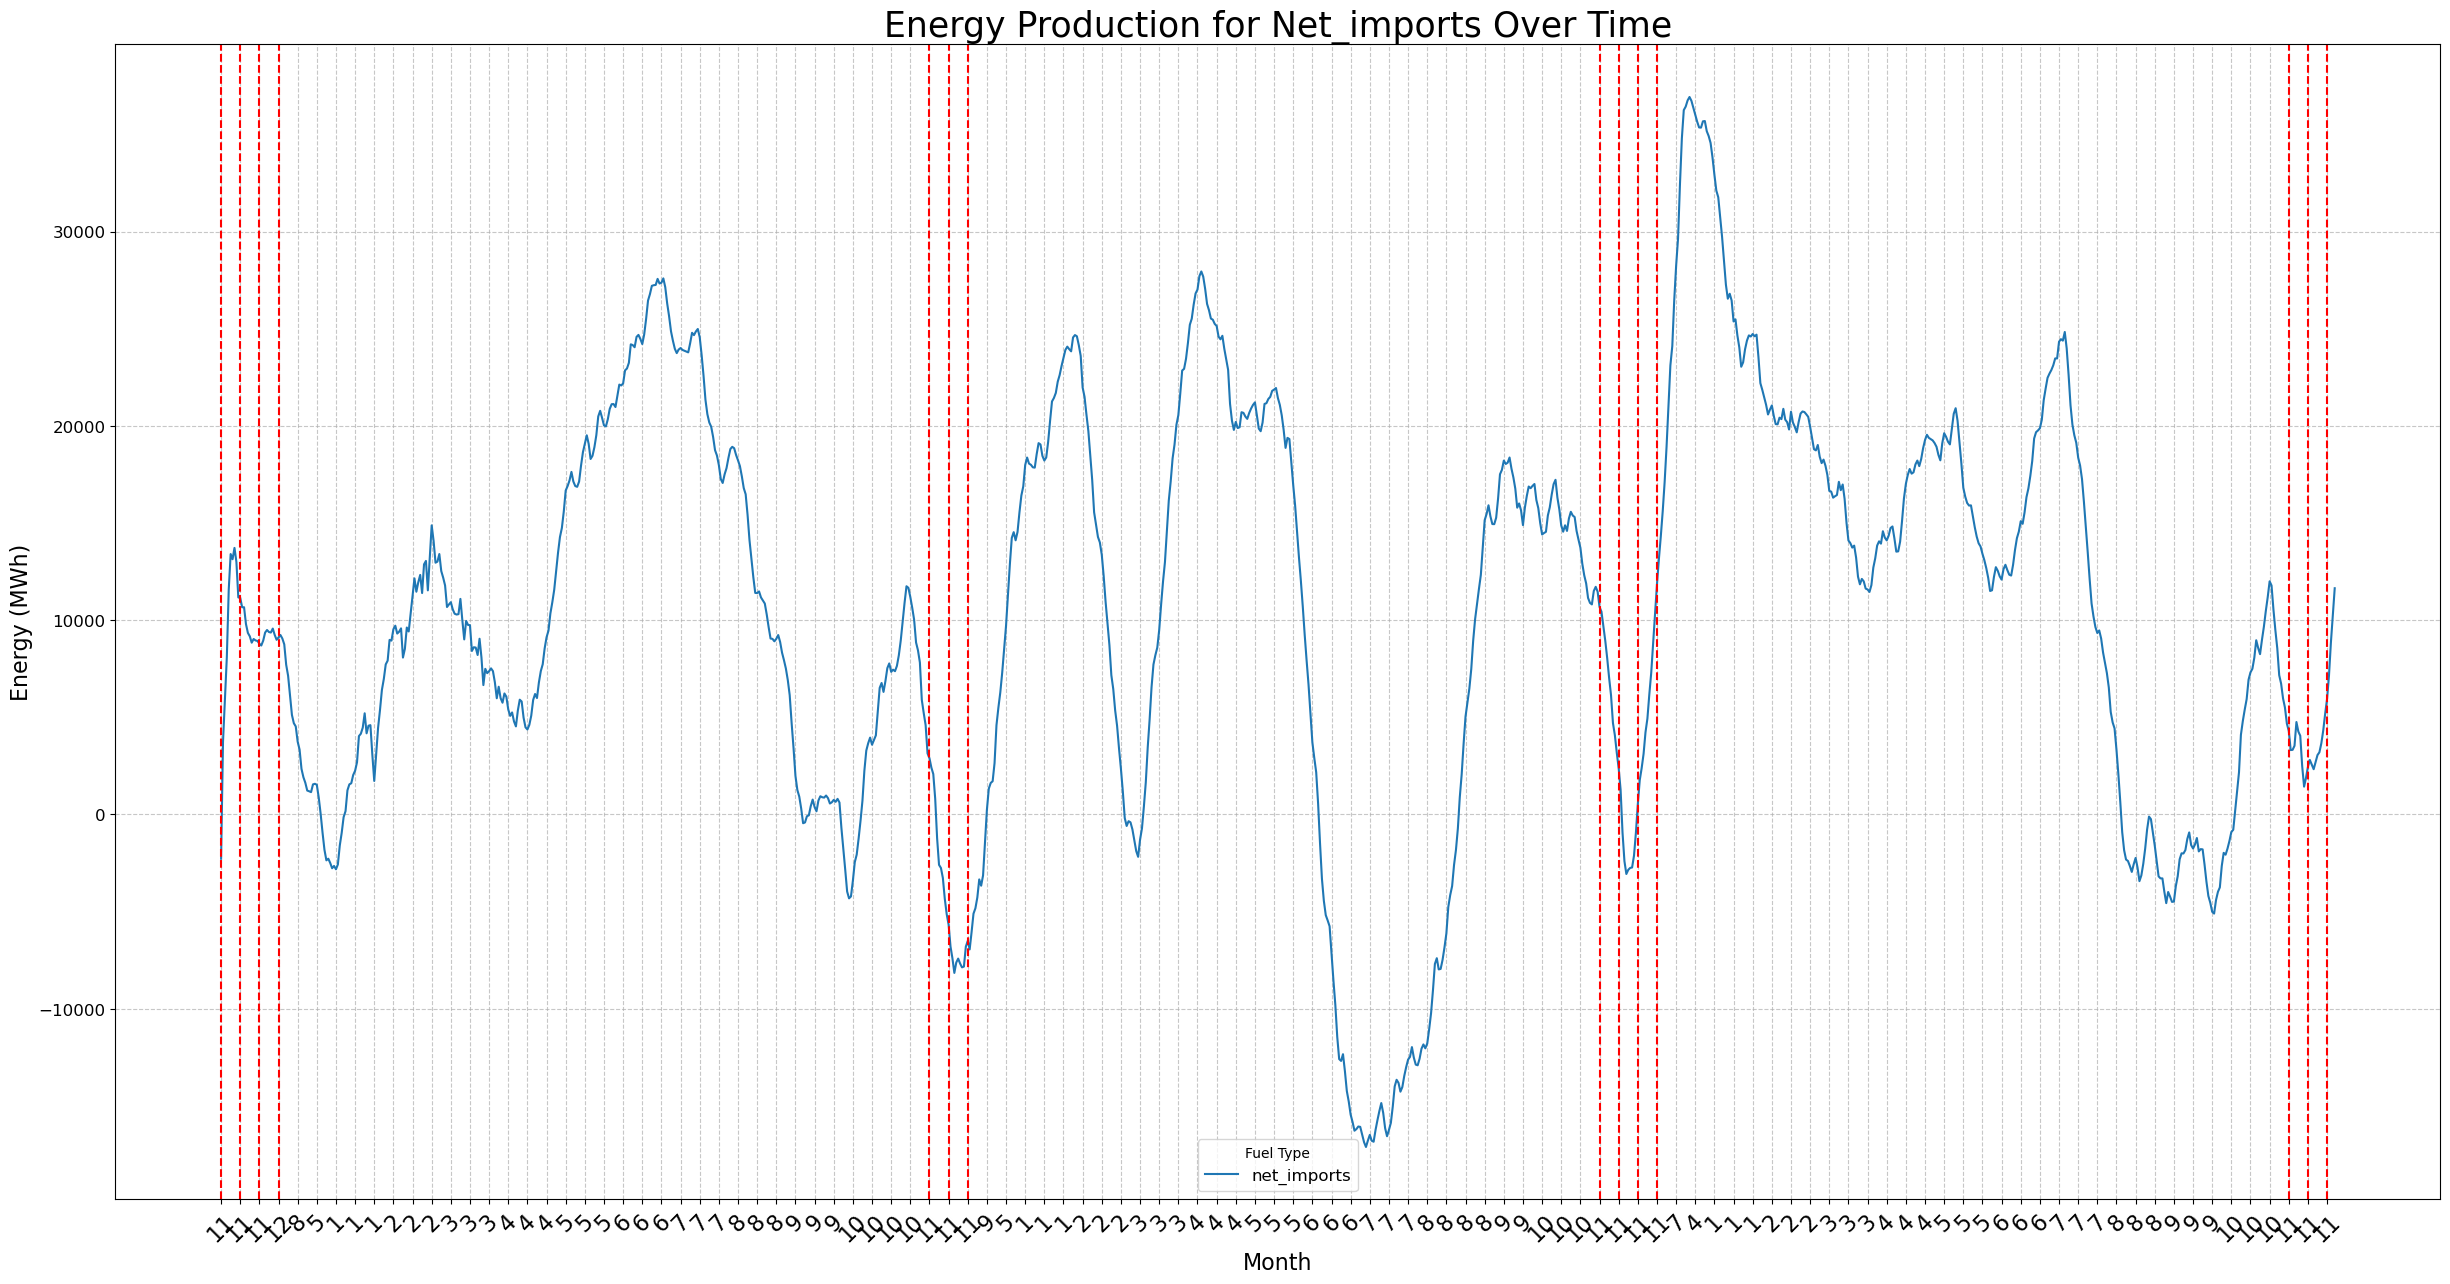

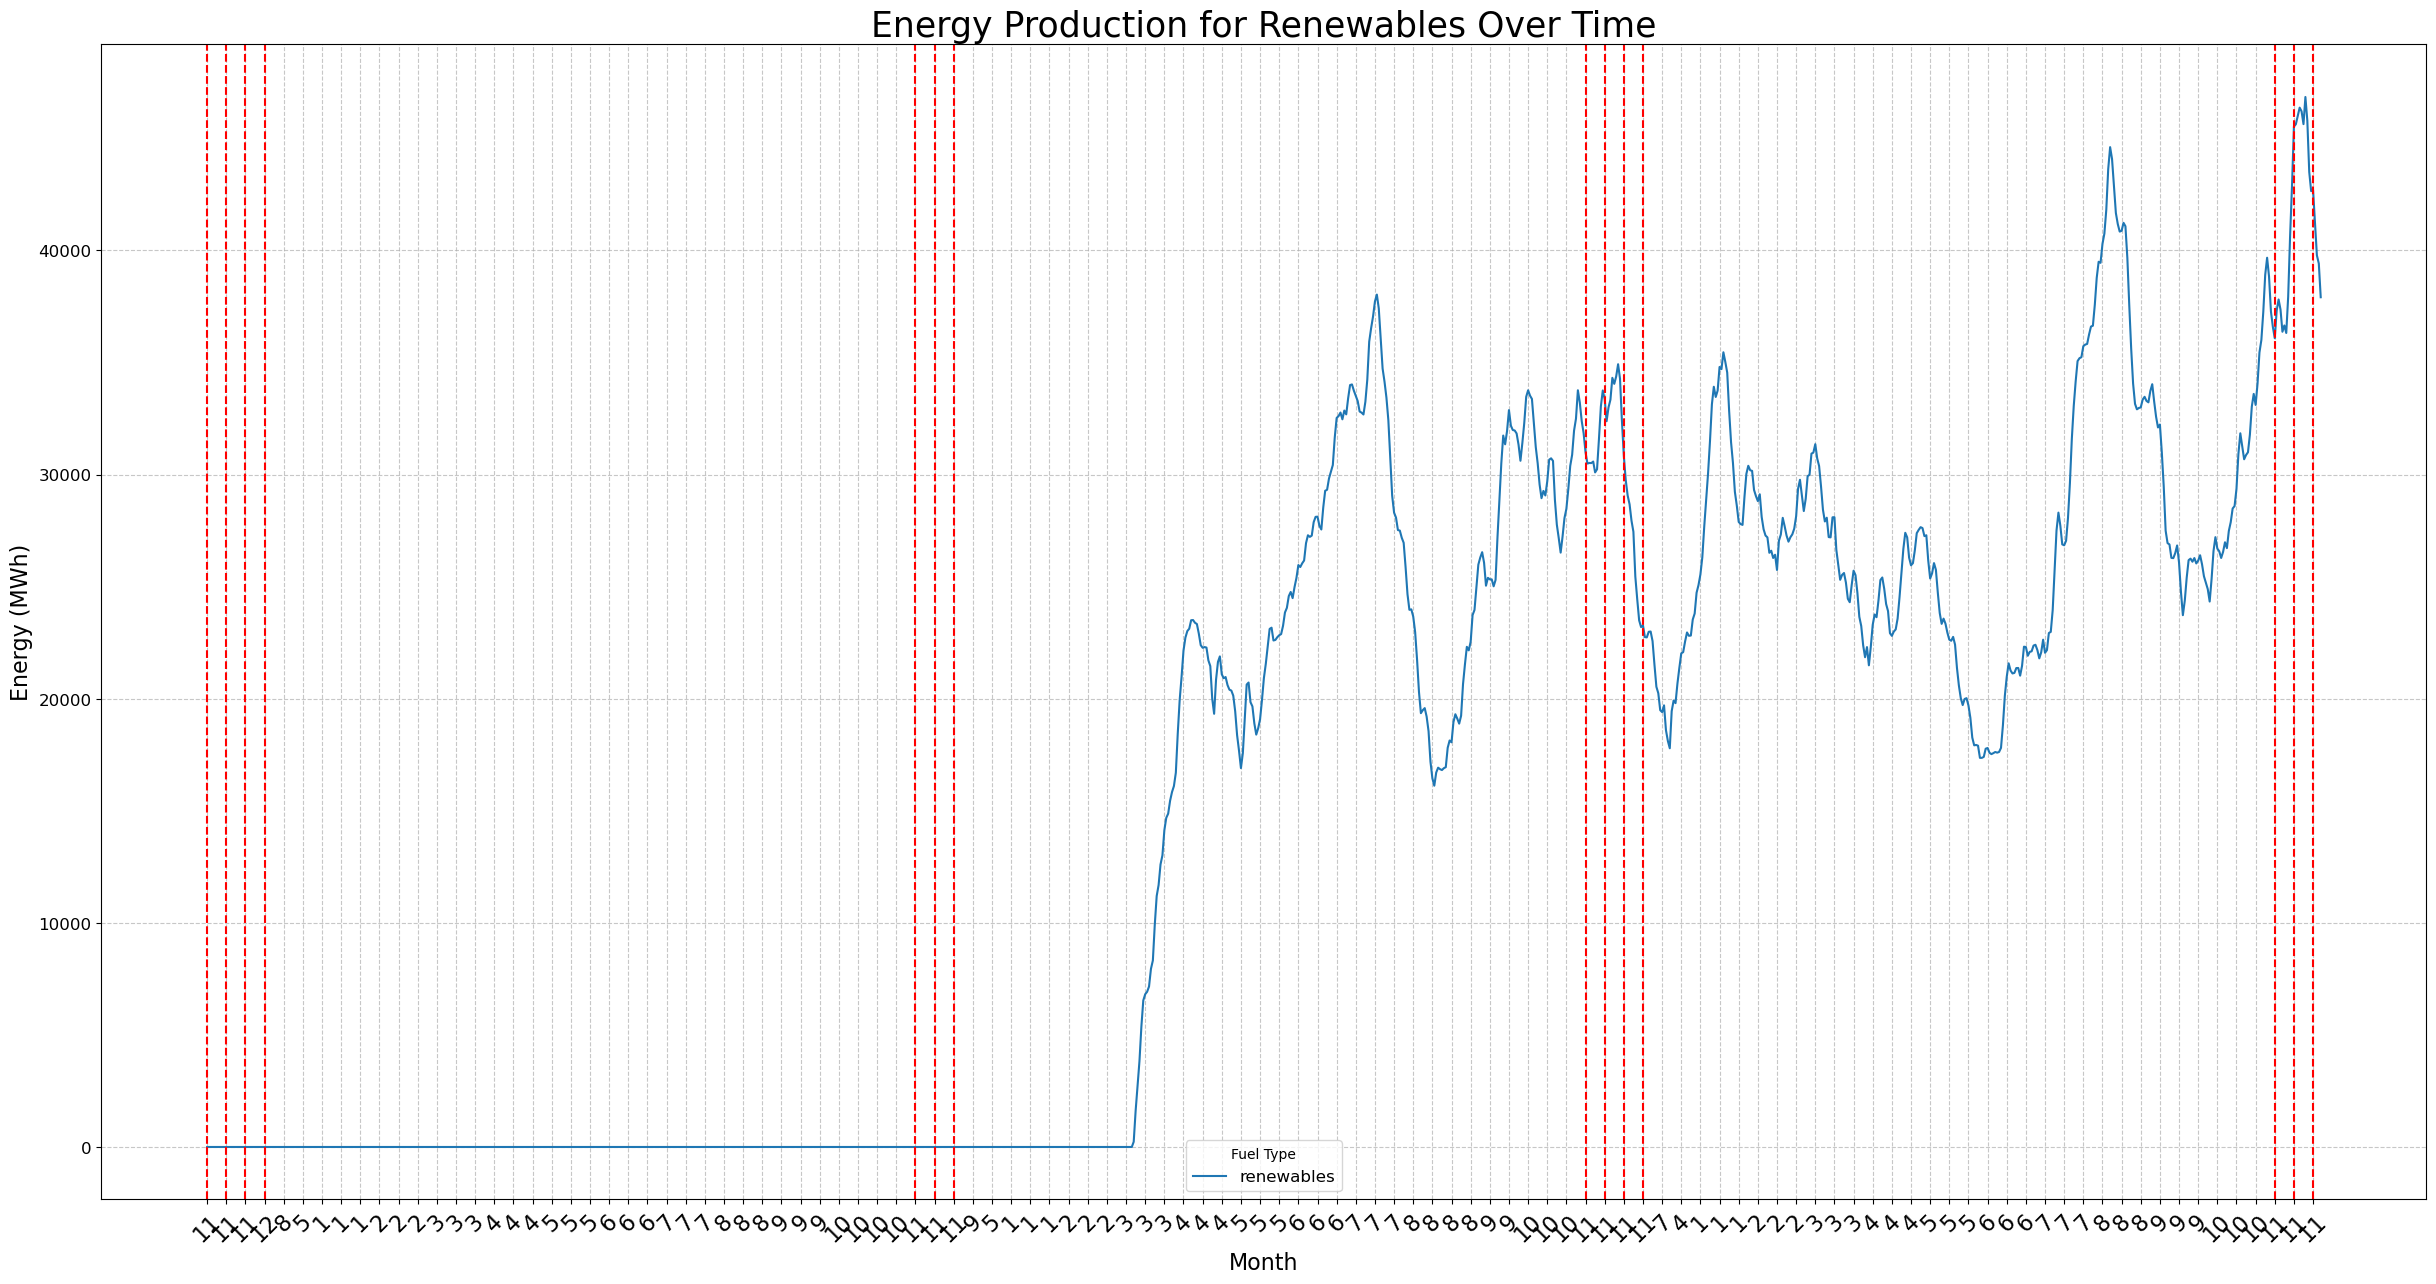

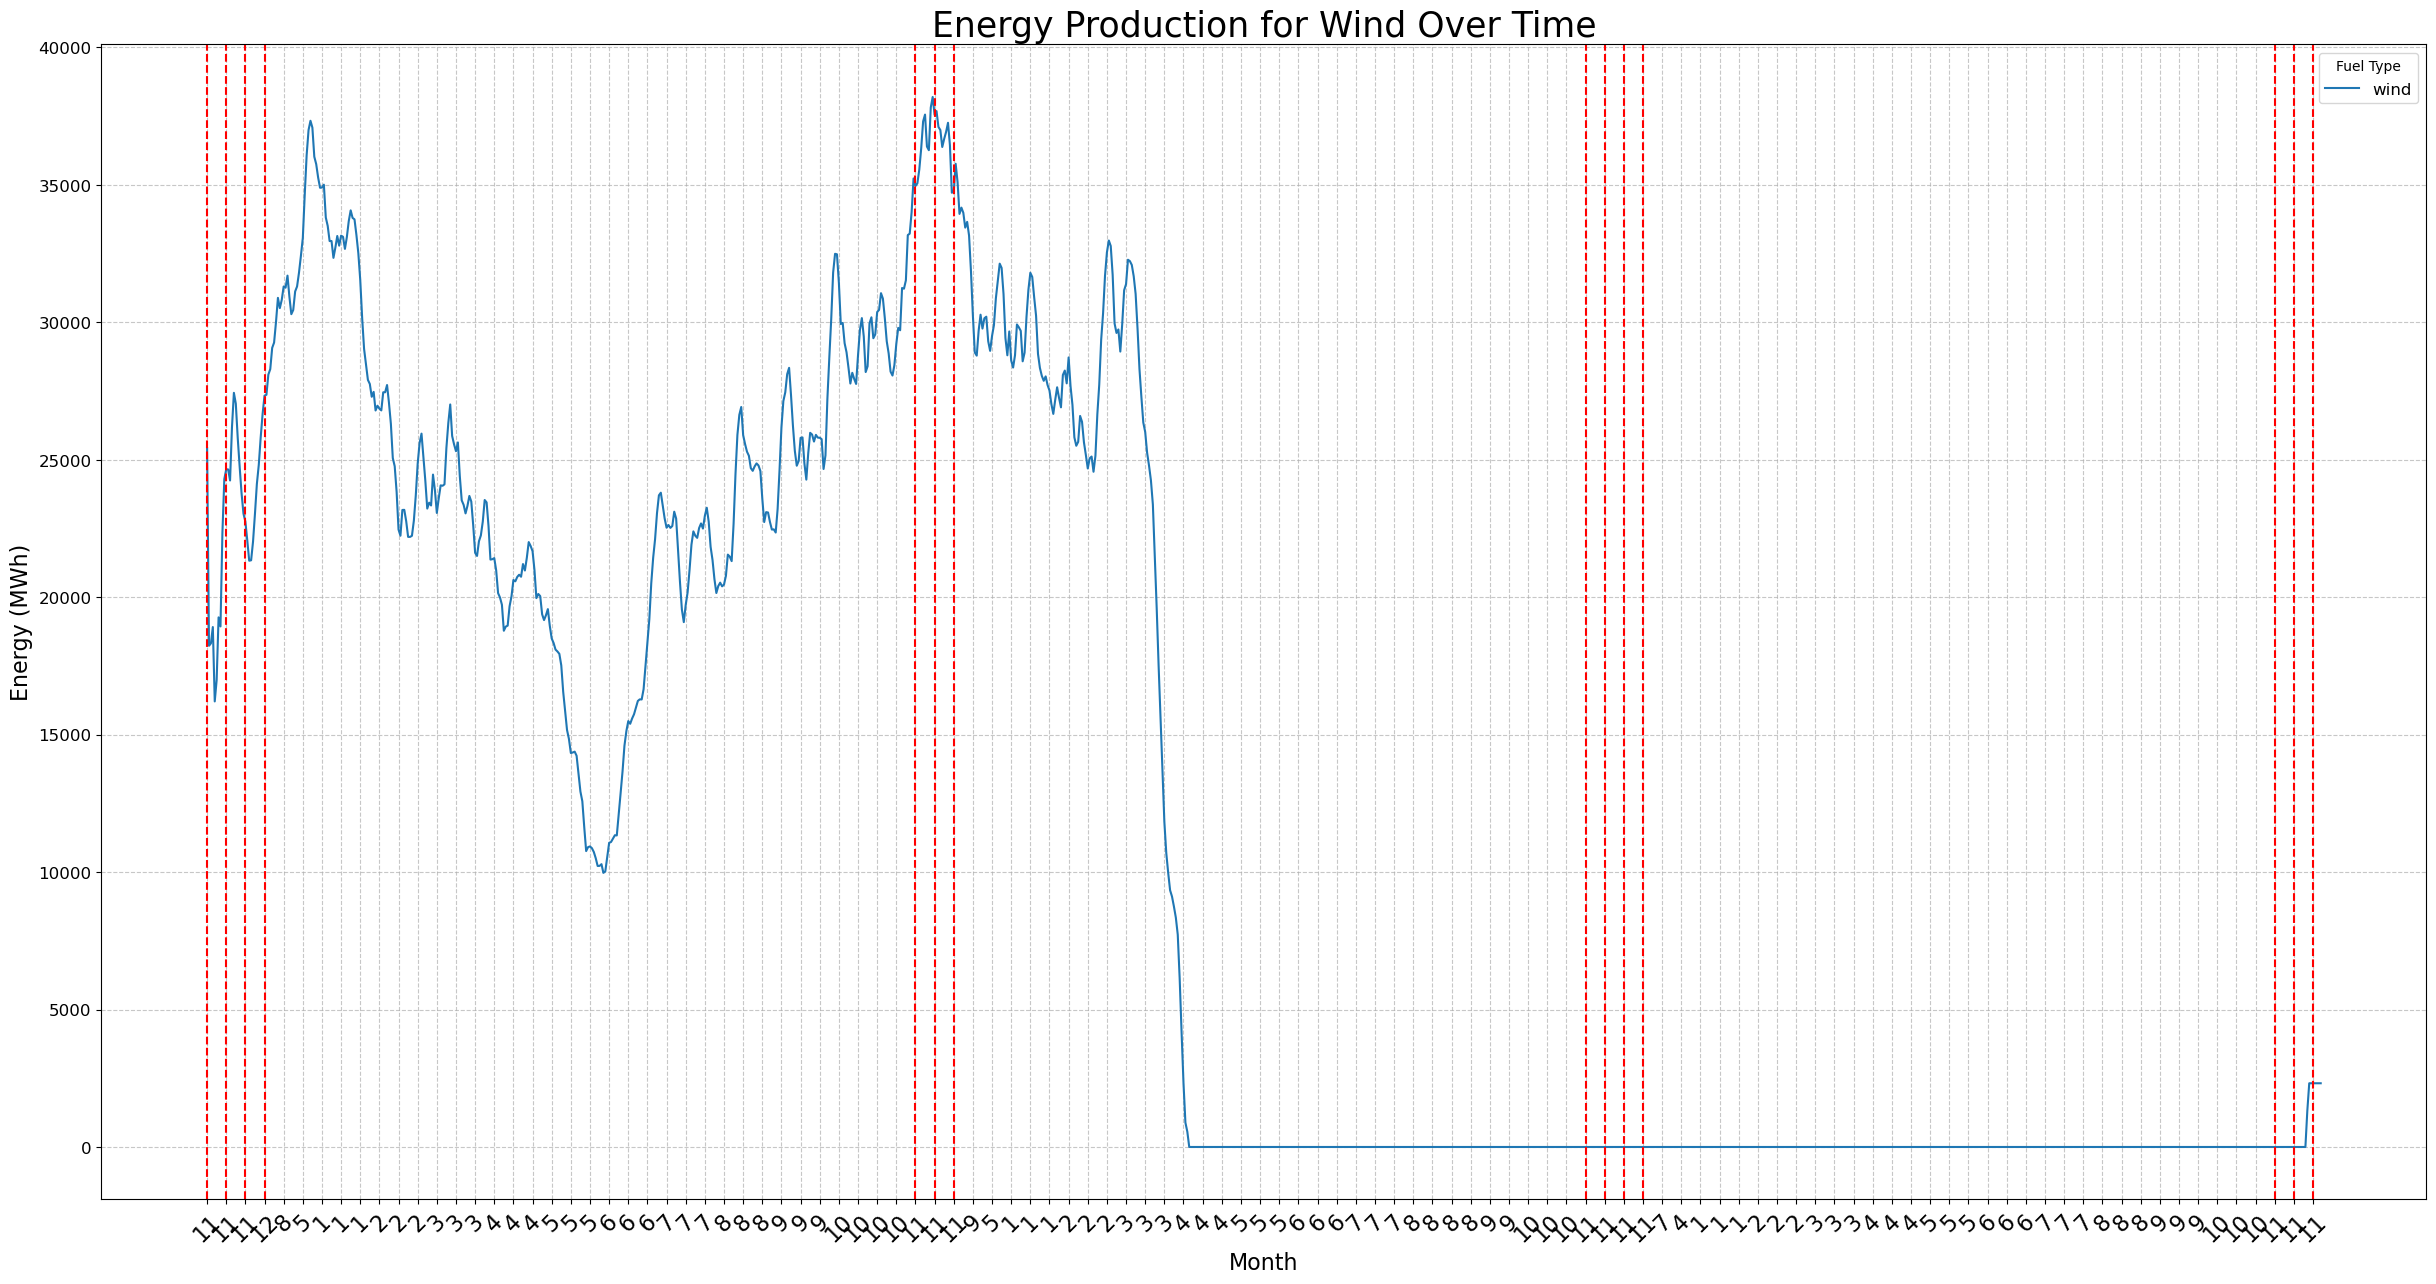

In [19]:
fuel_columns = ['gas', 'hydroelectric', 'lignite', 'natural_gas', 
                'net_imports', 'renewables', 'wind']

# Loop through each fuel type
for fuel in fuel_columns:
    # Set up the figure
    plt.figure(figsize=(30, 15))
    
    # Plot the current fuel type
    plt.plot(
        range(len(rolling_table)),  # Using row indices as x-axis
        rolling_table[fuel],       # Plot the values for the current fuel type
        label=fuel                 # Add label for the legend
    )
    
    # Define x-ticks
    ticks = rolling_table.index[::10]  # Take every 10th index
    labels = rolling_table['month'].iloc[::10]  # Corresponding labels

    plt.xticks(
        ticks=ticks,  # Positions for the ticks
        labels=labels,  # Labels for the ticks
        rotation=45,  # Rotate labels for better readability
        fontsize=16
    )

    plt.yticks(fontsize=12)

    # Draw vertical red lines for ticks with label '12'
    for tick, label in zip(ticks, labels):
        if label == 12 or label == 11:
            plt.axvline(x=tick, color='red', linestyle='--', linewidth=1.5)
    
    # Adding titles and labels
    plt.title(f'Energy Production for {fuel.capitalize()} Over Time', fontsize=25)
    plt.xlabel('Month', fontsize=16)
    plt.ylabel('Energy (MWh)', fontsize=16)

    # Adding a legend to differentiate the current fuel type
    plt.legend(title='Fuel Type', fontsize=12)

    # Display the plot
    plt.grid(visible=True, linestyle='--', alpha=0.7)

    plt.savefig(f'../outputs/graphs/energy/{fuel}_energy_production_progression.png')
    plt.show()


In [20]:
energy_trade = energy[energy['fuel'] == 'Net Imports (Imports - Exports)'].reset_index(drop=True)
energy_total = energy[energy['fuel'] == 'Total'].reset_index(drop=True).rename(columns={'energy_mwh': 'total_energy_mwh'})
energy_total

,date,total_energy_mwh,fuel,percentage,year,month,day,absolute_energy_mwh
0,2020-11-30 19:00:00,142704,Total,1.004,2020,11,30,143274.816
1,2020-12-01 19:00:00,143824,Total,1.000,2020,12,1,143824.000
2,2020-12-02 19:00:00,141005,Total,1.000,2020,12,2,141005.000
3,2020-12-03 19:00:00,137215,Total,1.000,2020,12,3,137215.000
4,2020-12-04 19:00:00,126359,Total,1.000,2020,12,4,126359.000
...,...,...,...,...,...,...,...,...
1105,2023-12-26 00:00:00,93077,Total,1.000,2023,12,26,93077.000
1106,2023-12-27 00:00:00,103279,Total,1.000,2023,12,27,103279.000
1107,2023-12-28 00:00:00,106065,Total,1.000,2023,12,28,106065.000
1108,2023-12-29 00:00:00,108428,Total,1.000,2023,12,29,108428.000


In [21]:
energy_trade = pd.concat([energy_trade, energy_total['total_energy_mwh']], axis=1).drop(columns=['fuel', 'date'])
energy_trade

,energy_mwh,percentage,year,month,day,absolute_energy_mwh,total_energy_mwh
0,-2280,-0.010000,2020,11,30,22.800000,142704
1,9736,0.067694,2020,12,1,659.067304,143824
2,10327,0.073239,2020,12,2,756.334378,141005
3,14607,0.110000,2020,12,3,1606.770000,137215
4,25489,0.201719,2020,12,4,5141.613348,126359
...,...,...,...,...,...,...,...
1105,23745,0.255111,2023,12,26,6057.619229,93077
1106,27957,0.270694,2023,12,27,7567.790635,103279
1107,31606,0.297987,2023,12,28,9418.179758,106065
1108,25885,0.238730,2023,12,29,6179.522125,108428


In [22]:
mean_energy_trade = energy_trade.groupby(['year', 'month', 'day'])[['energy_mwh','total_energy_mwh']].mean().reset_index()
mean_energy_trade.rename(columns={'energy_mwh': 'mean_energy_mwh', 'total_energy_mwh': 'mean_total_energy_mwh'}, inplace=True)

rolling_energy_trade = mean_energy_trade.rolling(window=30, step=1, min_periods=1).mean().sort_values(['year', 'month', 'day'], ascending=True)

rolling_energy_trade[['year', 'month', 'day']] = rolling_energy_trade[['year', 'month', 'day']].astype(dtype='int', copy=False)
rolling_energy_trade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1105 entries, 0 to 1104
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   1105 non-null   int64  
 1   month                  1105 non-null   int64  
 2   day                    1105 non-null   int64  
 3   mean_energy_mwh        1105 non-null   float64
 4   mean_total_energy_mwh  1105 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 43.3 KB


In [23]:
sc = MinMaxScaler()

scaled_energies = sc.fit_transform(rolling_energy_trade[['mean_energy_mwh', 'mean_total_energy_mwh']])
scaled_energies = pd.DataFrame(scaled_energies, columns=['mean_energy_mwh', 'mean_total_energy_mwh'])

In [24]:
scaled_rolling_table = pd.concat(
    [rolling_table.loc[:, ['year', 'month', 'day']],
     scaled_energies
    ], axis=1
).reset_index(drop=True)

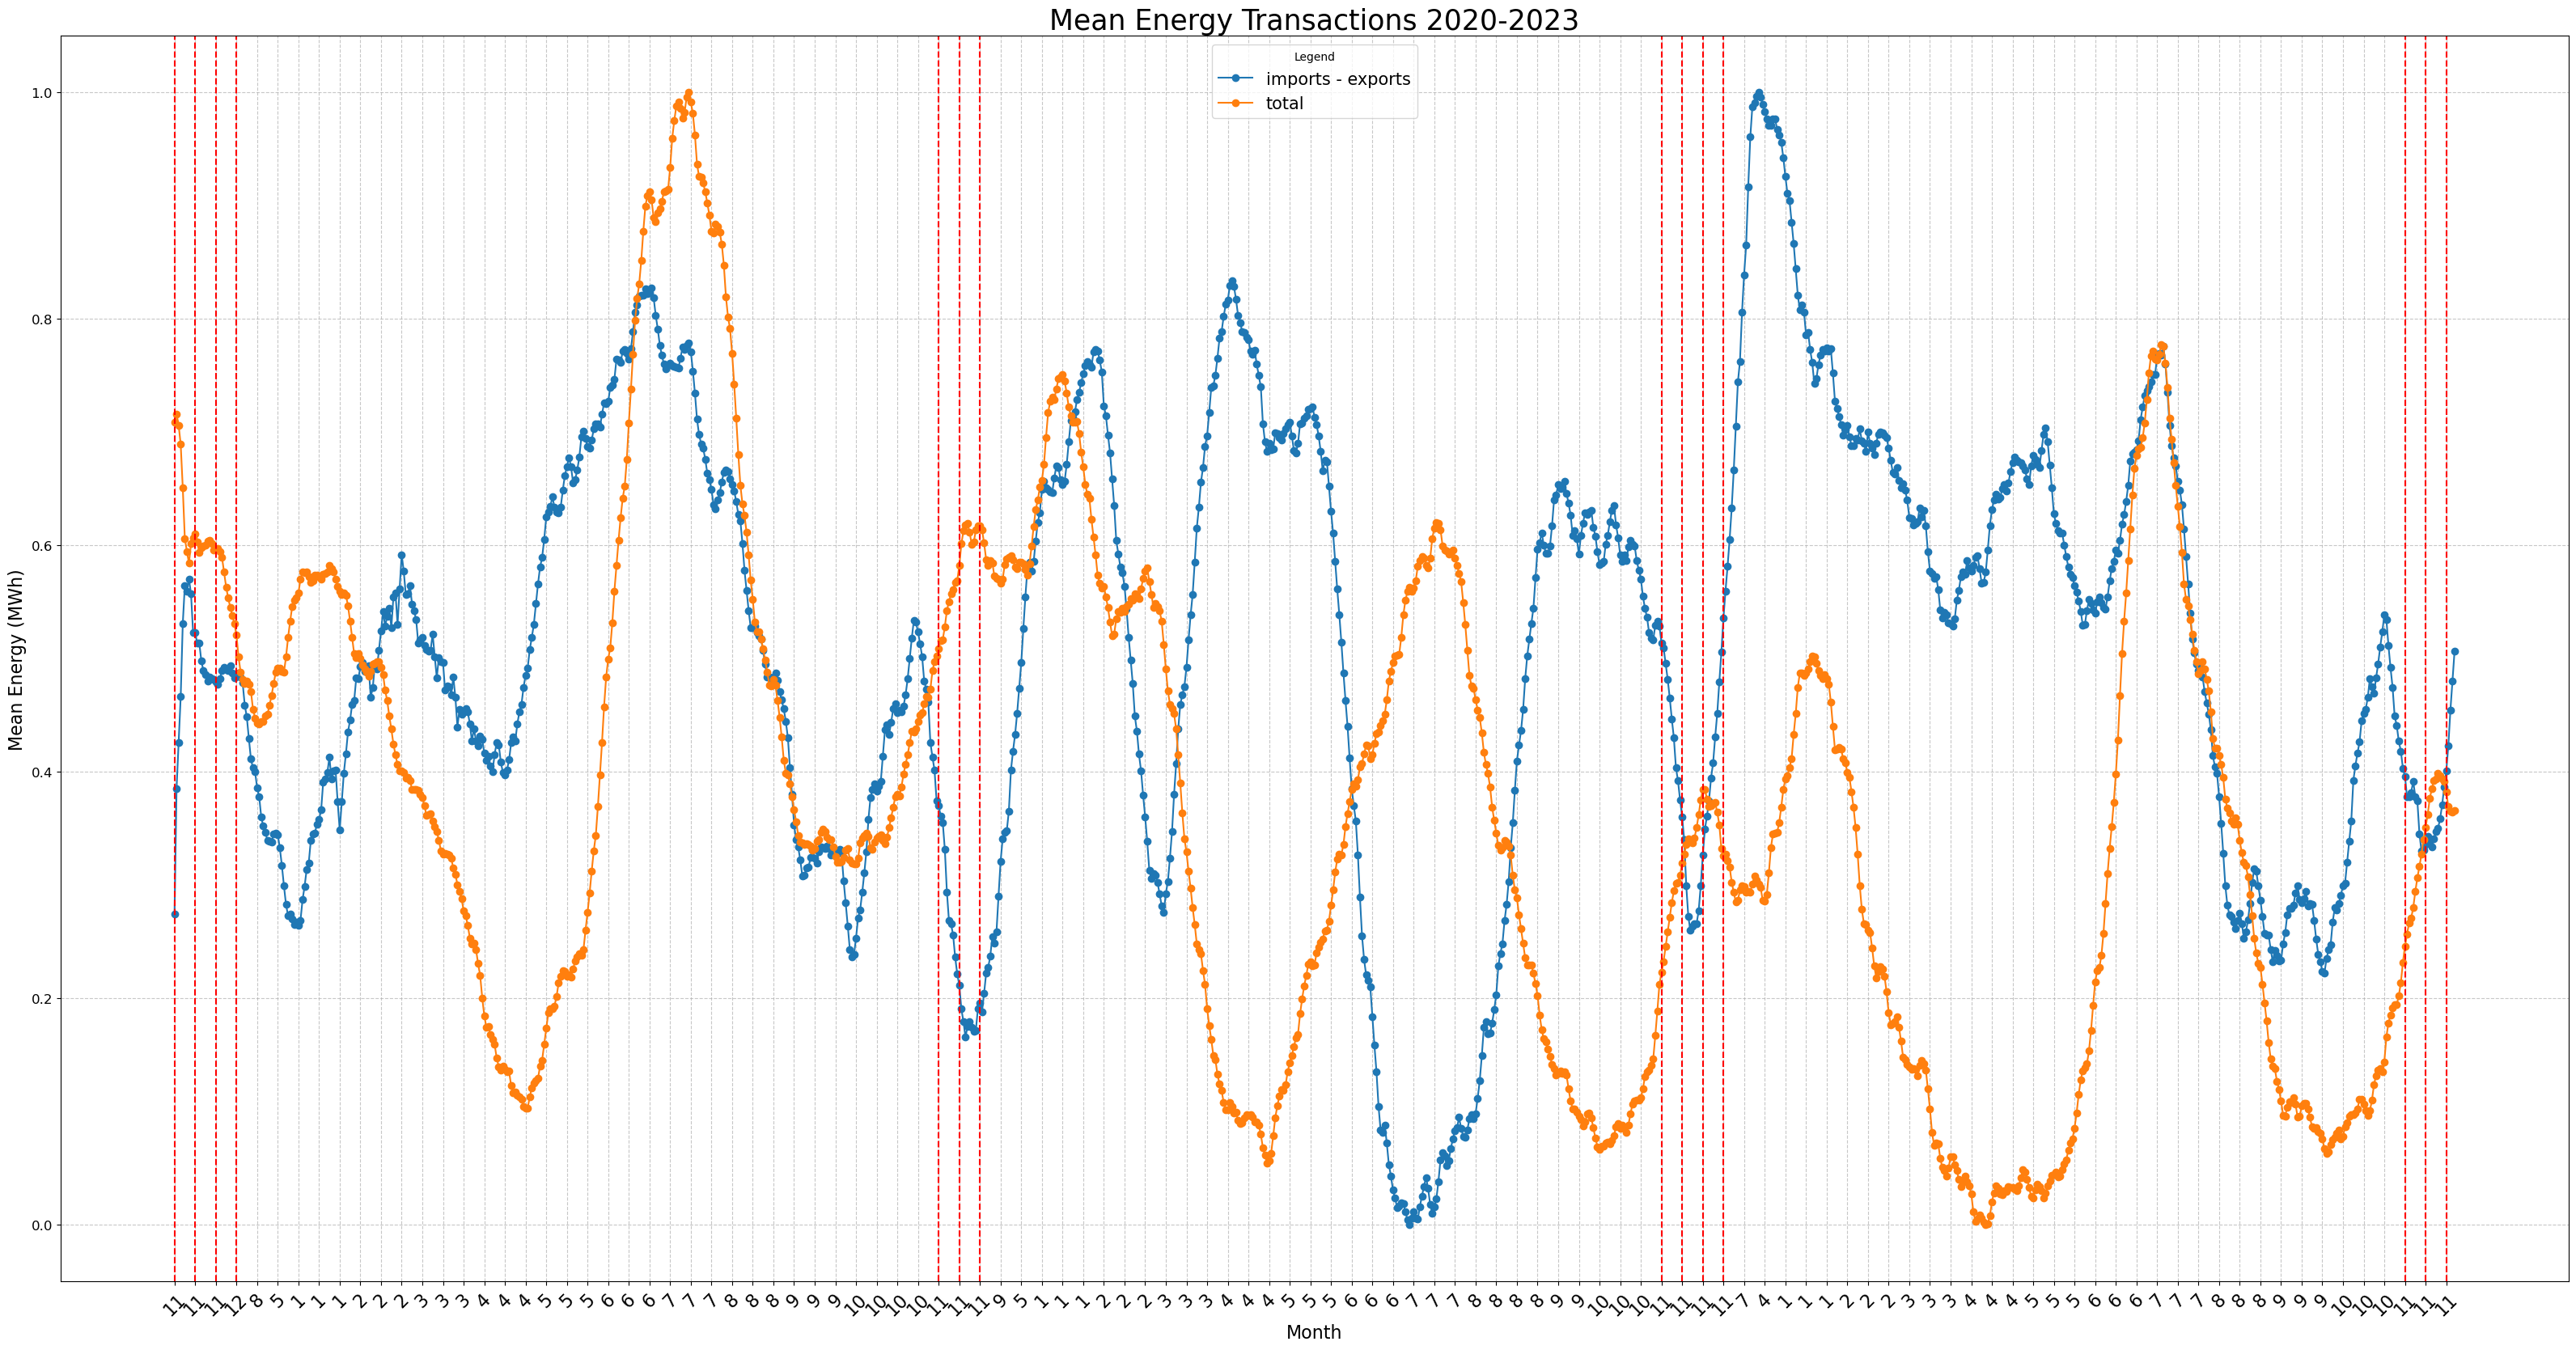

In [25]:
plt.figure(figsize=(40, 20))  
plt.plot(scaled_rolling_table.index, scaled_rolling_table['mean_energy_mwh'], marker='o')
plt.plot(scaled_rolling_table.index, scaled_rolling_table['mean_total_energy_mwh'], marker='o')

# Adding titles and labels
plt.title('Mean Energy Transactions 2020-2023', fontsize=25)
plt.xlabel('Month', fontsize=16)
plt.ylabel('Mean Energy (MWh)', fontsize=16)

# Set x-ticks to show every 5th day
ticks = scaled_rolling_table.index[::10]  # Take every 10th index to avoind crouding the x-axis

labels = scaled_rolling_table['month'].iloc[::10]  # Corresponding labels

plt.xticks(
    ticks=ticks,  # Positions for the ticks
    labels=labels,  # Labels for the ticks
    rotation=45,  # Rotate labels for better readability
    fontsize=16
)

plt.yticks(fontsize=12)

# Draw vertical red lines for ticks with label '12'
for tick, label in zip(ticks, labels):
    if label == 12 or label == 11:
        plt.axvline(x=tick, color='red', linestyle='--', linewidth=1.5)

# Display grid for better readability
plt.grid(visible=True, linestyle='--', alpha=0.7)
plt.legend(title='Legend', labels=['imports - exports', 'total'], fontsize=15)

plt.savefig('../outputs/graphs/energy/mean_energy_net_total.png', dpi=300, bbox_inches='tight')  # Save as PNG with high resolution
# Show the plot

plt.show()


In the scaled graph above we notice that during certain seasons (June-July & March-May) energy trade and total energy follow similar trends (downwards and upwardds respectively). A ratio plot will give a clearer view on wether energy is traded consistently when the energy needed is increased or decreased.

To avoid large numeric errors, we will calculate the ratio in non-scaled values of imported/exported and total energy values.

In [26]:
pivot_table['ratio_net_total'] = pivot_table['net_imports'] / pivot_table['total']

columns_to_plot = ['year', 'month', 'day', 'ratio_net_total']
ratio = pivot_table[columns_to_plot].copy() 

ratio['rolling_ratio'] = ratio['ratio_net_total'].rolling(window=30, min_periods=1).mean()

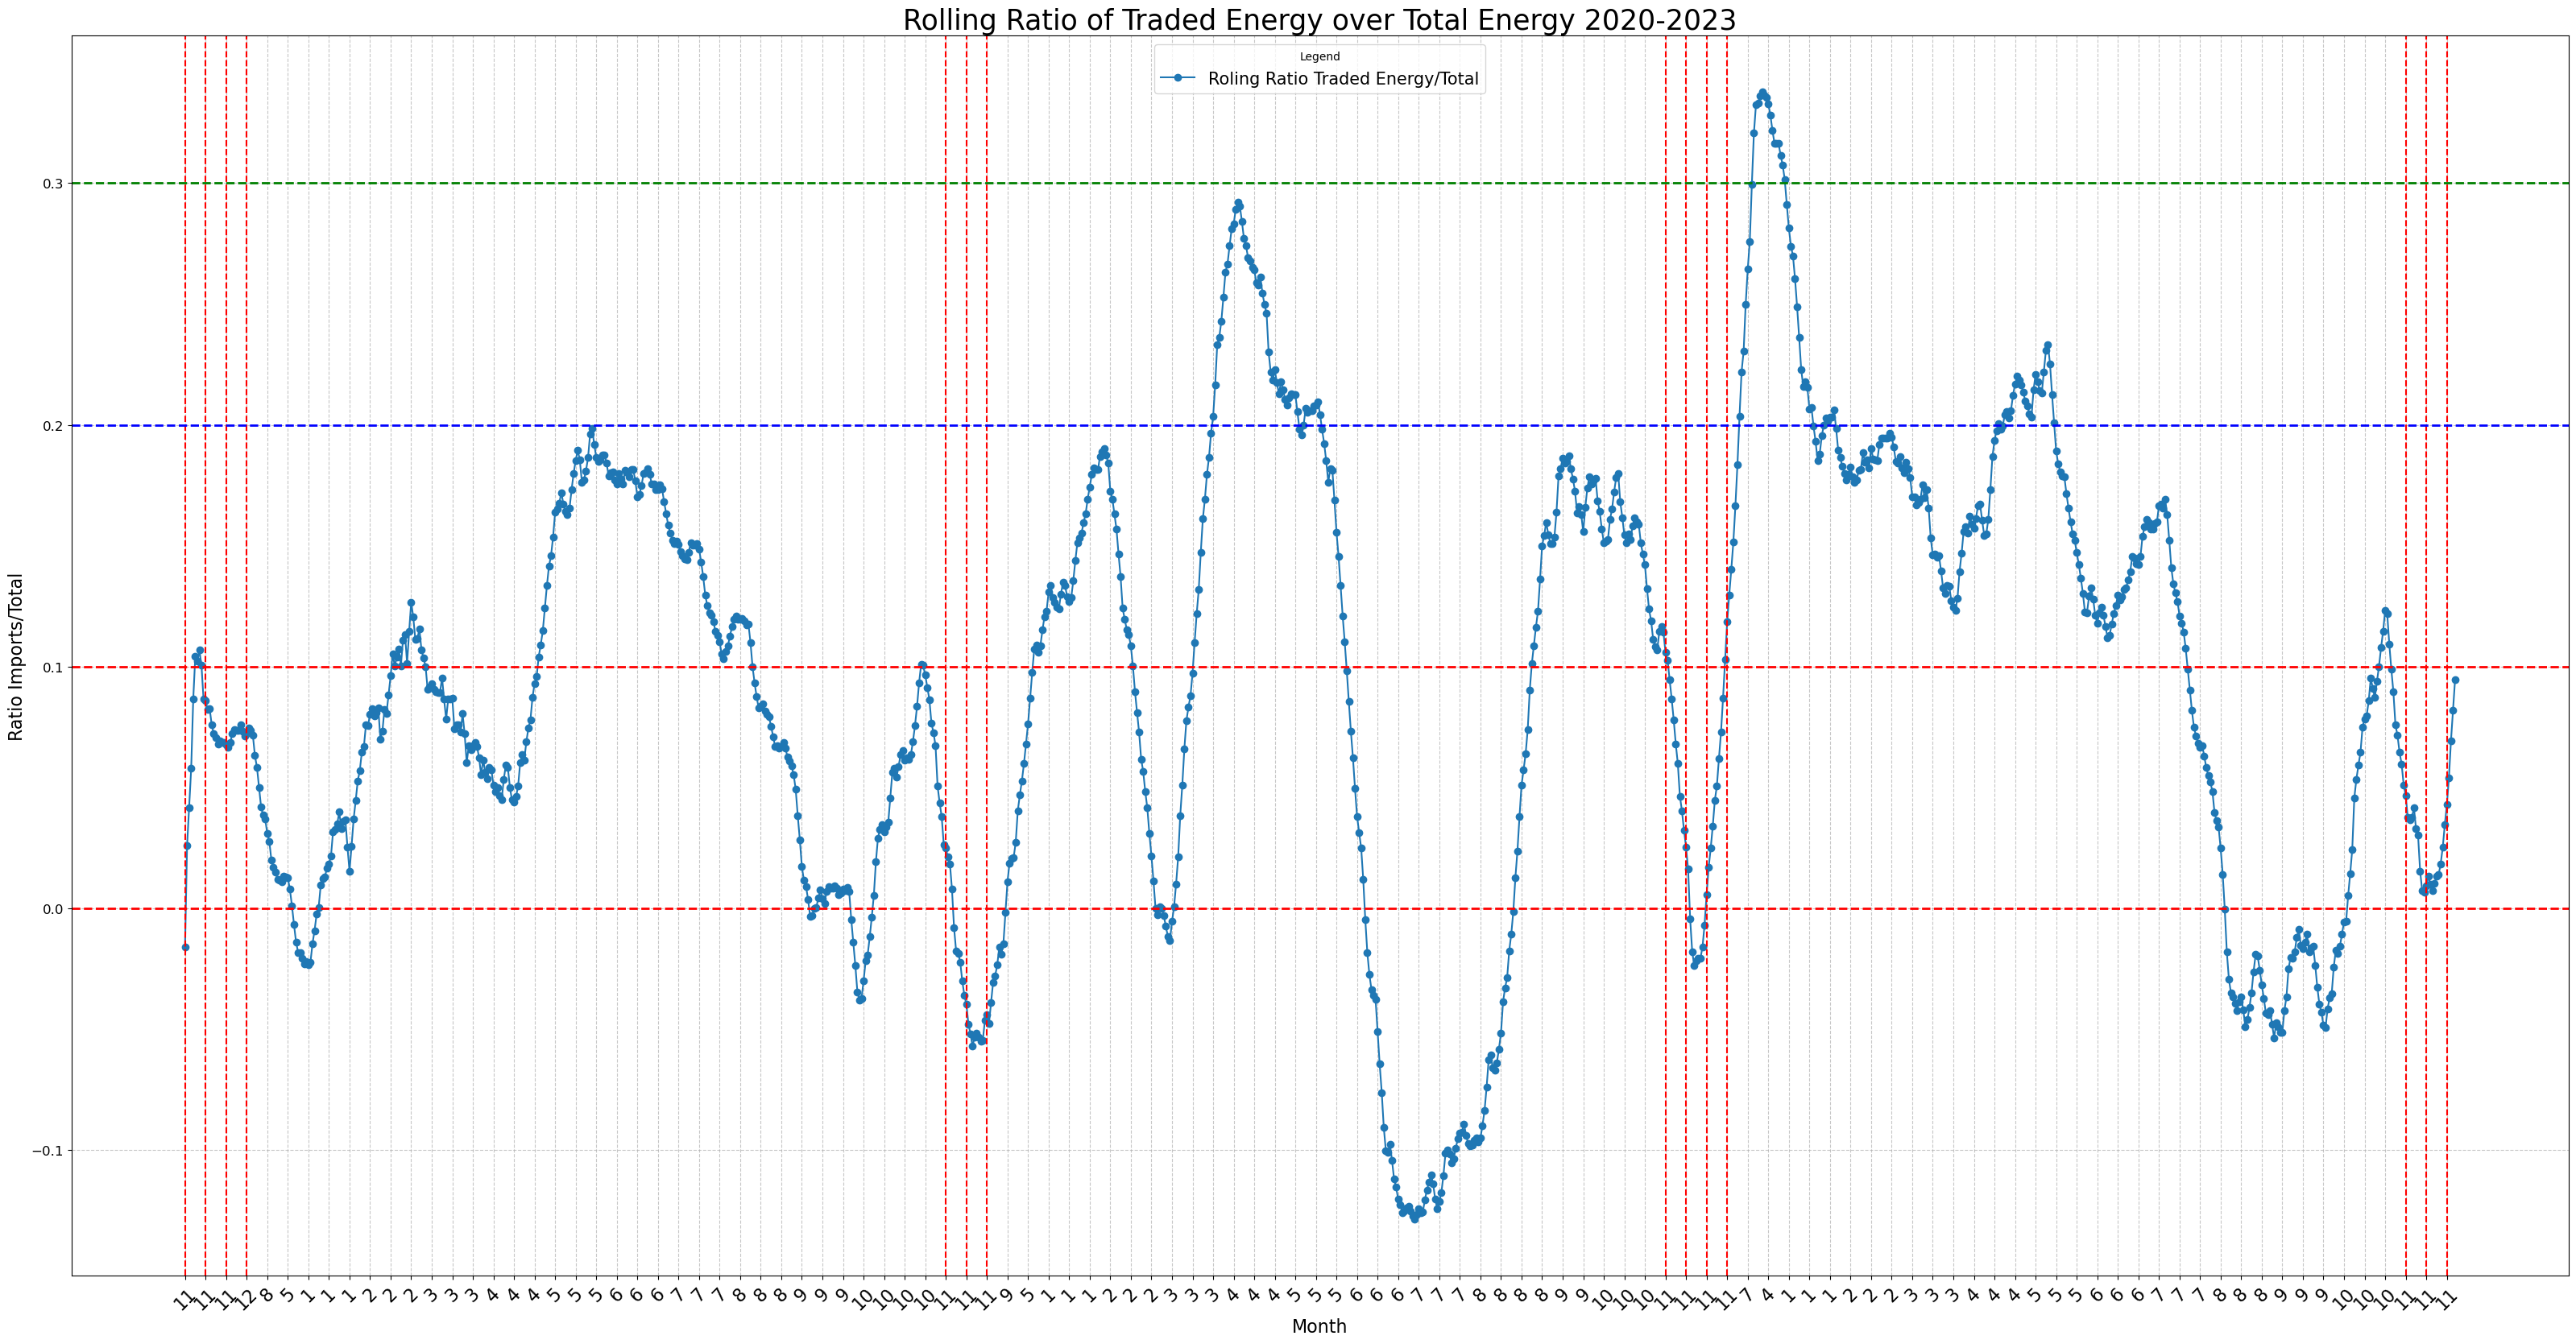

In [27]:
plt.figure(figsize=(40, 20))  
plt.plot(ratio.index, ratio['rolling_ratio'], marker='o')

# Adding titles and labels
plt.title('Rolling Ratio of Traded Energy over Total Energy 2020-2023', fontsize=25)
plt.xlabel('Month', fontsize=16)
plt.ylabel('Ratio Imports/Total', fontsize=16)

# Set x-ticks to show every 5th day
ticks = scaled_rolling_table.index[::10]  # Take every 10th index to avoind crouding the x-axis

labels = scaled_rolling_table['month'].iloc[::10]  # Corresponding labels

plt.xticks(
    ticks=ticks,  # Positions for the ticks
    labels=labels,  # Labels for the ticks
    rotation=45,  # Rotate labels for better readability
    fontsize=16
)

plt.yticks(fontsize=12)

# Draw vertical red lines for ticks with label '12'
for tick, label in zip(ticks, labels):
    if label == 12 or label == 11:
        plt.axvline(x=tick, color='red', linestyle='--', linewidth=1.5)

# Display grid for better readability
plt.grid(visible=True, linestyle='--', alpha=0.7)
plt.legend(title='Legend', labels=['Roling Ratio Traded Energy/Total'], fontsize=15)

plt.axhline(y=0, color='red', linestyle='--', linewidth=2)   
plt.axhline(y=0.1, color='red', linestyle='--', linewidth=2)  
plt.axhline(y=0.2, color='blue', linestyle='--', linewidth=2)  
plt.axhline(y=0.3, color='green', linestyle='--', linewidth=2)  


plt.savefig('../outputs/graphs/energy/energy_ratio_net_total.png', dpi=300, bbox_inches='tight')  # Save as PNG with high resolution
# Show the plot
plt.show()


In the graph above we see that  the Ratio of traded energy over total energy is mostly positive. This means that most of the time Greece buys energy from traders instead of selling any surplus.

The 2 red horizontal lines depict 10% of the total energy bought whereas the blue horizontal line depicts the 20% of total energy bought.

- We clearly see that Greece buy more energy with each passing year
- In 2021 more than half of the year and a quarter of the year 10% and 20% of the total energy was purchased from traders.
- In 2022 about half of the year more than 10% of the total energy the country consumed was bought from traders.
- In 2023 the percentage of energy bought surpassed 30%

These increases in energy bought can be higly linked to the increase in product prices.
Such increases could be cause the increase in market prices because energy is needed to produce products. Therefore, the increases in can quite directly cause the increase of product prices.